# EDA Report — ViEcomNER Gold Dataset

> **Mục tiêu:** Phân tích khám phá dữ liệu (EDA) cho bộ dữ liệu gán nhãn NER trên tiêu đề sản phẩm thương mại điện tử tiếng Việt.

**Cấu trúc Notebook:**

0. Nạp & tiền xử lý dữ liệu
1. Thống kê tổng quát 
2. Phân bố nhãn — Overall / Train-Dev-Test / Industry Group / IAA / Co-occurrence 
3. Phân bố độ dài span theo nhãn 
4. Phân tích vị trí thực thể 
5. Phân tích Code-switching Anh–Việt 
6. Phân tích tính nhất quán & xung đột nhãn

---
## 0. Nạp dữ liệu & Cấu hình môi trường

In [124]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style="whitegrid", palette="muted")


def parse_json(file_path):
    data_list = []

    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            data = json.loads(line)

            base_info = {
                'id': data.get('id', data.get('original_id', '')),
                'platform': data.get('platform', 'unknown'),
                'industry_group': data.get('industry_group', 'unknown'),
                'category_l3': data.get('category_l3', ''),
                'full_text': data.get('text', ''),
                'quality': data.get('quality', 'unknown'),
                'split': data.get('split', 'unassigned'),
                'is_iaa_sample': data.get('is_iaa_sample', False)
            }

            entities = data.get('entities', [])

            if not entities:
                row = base_info.copy()
                row.update({
                    'start_char': None,
                    'end_char': None,
                    'entity_text': None,
                    'label': 'O',
                    'entity_length': 0
                })
                data_list.append(row)
            else:
                for ent in entities:
                    row = base_info.copy()

                    start = ent.get('start_char')
                    end = ent.get('end_char')
                    ent_text = ent.get('text')
                    if not ent_text and start is not None and end is not None:
                        ent_text = base_info['full_text'][start:end]

                    row.update({
                        'start_char': start,
                        'end_char': end,
                        'entity_text': ent_text,
                        'label': ent.get('label', 'O'),
                        'entity_length': len(str(ent_text)) if ent_text else 0
                    })
                    data_list.append(row)

    return pd.DataFrame(data_list)


file_path = '/kaggle/input/datasets/hoangyendo/viecomner-gold/full_dataset.jsonl'

df = parse_json(file_path)

print(f"Bảng dữ liệu có tổng cộng {len(df)} dòng.")
print("\n=== THỐNG KÊ CÁC CỘT ĐƯỢC TRÍCH XUẤT ===")
print(df.info())

print("\n=== XEM THỬ 5 DÒNG ĐẦU TIÊN ===")
display(df.head(5))

Bảng dữ liệu có tổng cộng 18837 dòng.

=== THỐNG KÊ CÁC CỘT ĐƯỢC TRÍCH XUẤT ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18837 entries, 0 to 18836
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              18837 non-null  object
 1   platform        18837 non-null  object
 2   industry_group  18837 non-null  object
 3   category_l3     18837 non-null  object
 4   full_text       18837 non-null  object
 5   quality         18837 non-null  object
 6   split           18837 non-null  object
 7   is_iaa_sample   18837 non-null  bool  
 8   start_char      18837 non-null  int64 
 9   end_char        18837 non-null  int64 
 10  entity_text     18837 non-null  object
 11  label           18837 non-null  object
 12  entity_length   18837 non-null  int64 
dtypes: bool(1), int64(3), object(9)
memory usage: 1.7+ MB
None

=== XEM THỬ 5 DÒNG ĐẦU TIÊN ===


,id,platform,industry_group,category_l3,full_text,quality,split,is_iaa_sample,start_char,end_char,entity_text,label,entity_length
0,lazada_13241,lazada,beauty & health,phan-ma,Má Hồng Kem Maybelline Căng Mọng Bền Màu 12H 4...,clean,train,False,0,11,Má Hồng Kem,PRODUCT_TYPE,11
1,lazada_13241,lazada,beauty & health,phan-ma,Má Hồng Kem Maybelline Căng Mọng Bền Màu 12H 4...,clean,train,False,12,22,Maybelline,BRAND,10
2,lazada_13241,lazada,beauty & health,phan-ma,Má Hồng Kem Maybelline Căng Mọng Bền Màu 12H 4...,clean,train,False,33,44,Bền Màu 12H,ATTRIBUTE,11
3,lazada_13241,lazada,beauty & health,phan-ma,Má Hồng Kem Maybelline Căng Mọng Bền Màu 12H 4...,clean,train,False,45,50,4.7ml,VOLUME_WEIGHT,5
4,lazada_13907,lazada,electronics & tech,pin-may-anh,"Pin Lisun CR-P2, 2CR5 pin 6V dùng cho máy ảnh ...",clean,train,False,0,3,Pin,PRODUCT_TYPE,3


In [126]:
df_titles = df.drop_duplicates(subset=['id']).copy()

df_titles['word_count'] = df_titles['full_text'].apply(lambda x: len(str(x).split()))
df_titles['char_count'] = df_titles['full_text'].apply(len)

entity_counts = df[df['label'] != 'O'].groupby('id').size().reset_index(name='entity_count')
df_titles = pd.merge(df_titles, entity_counts, on='id', how='left')
df_titles['entity_count'] = df_titles['entity_count'].fillna(0)
df_titles['entity_density'] = df_titles['entity_count'] / df_titles['word_count']

df_ent = df[df['label'] != 'O'].copy()

print(f"Số tiêu đề: {len(df_titles)}")
print(f"Số dòng thực thể: {len(df_ent)}")

Số tiêu đề: 2993
Số dòng thực thể: 18837


In [127]:
# BẢNG TỔNG HỢP THỐNG KÊ DATASET
print("BẢNG THỐNG KÊ TỔNG QUAN — ViEcomNER Gold Dataset")

splits = ['train', 'dev', 'test']
rows = []
for sp in splits:
    sub = df_titles[df_titles['split'] == sp]
    ent_sub = df_ent[df_ent['split'] == sp]
    rows.append({
        'Split':               sp.capitalize(),
        'Titles':              len(sub),
        'Tokens (avg/title)':  f"{sub['word_count'].mean():.1f}",
        'Entities':            len(ent_sub),
        'Entities/title':      f"{len(ent_sub)/max(len(sub),1):.1f}",
        'Labels (unique)':     ent_sub['label'].nunique(),
    })

# Tổng
rows.append({
    'Split':               'Total',
    'Titles':              len(df_titles),
    'Tokens (avg/title)':  f"{df_titles['word_count'].mean():.1f}",
    'Entities':            len(df_ent),
    'Entities/title':      f"{len(df_ent)/max(len(df_titles),1):.1f}",
    'Labels (unique)':     df_ent['label'].nunique(),
})

df_summary = pd.DataFrame(rows).set_index('Split')
display(df_summary)


BẢNG THỐNG KÊ TỔNG QUAN — ViEcomNER Gold Dataset


,Titles,Tokens (avg/title),Entities,Entities/title,Labels (unique)
Split,,,,,
Train,2396,19.7,15006,6.3,24
Dev,298,19.9,1896,6.4,24
Test,299,18.7,1935,6.5,23
Total,2993,19.6,18837,6.3,24


---
## 1. Thống kê tổng quát

Phân tích cấu trúc cơ bản của tiêu đề: độ dài, số lượng thực thể trên mỗi tiêu đề, mối quan hệ giữa độ dài và mật độ thực thể, và tỷ lệ ký tự được gán nhãn.

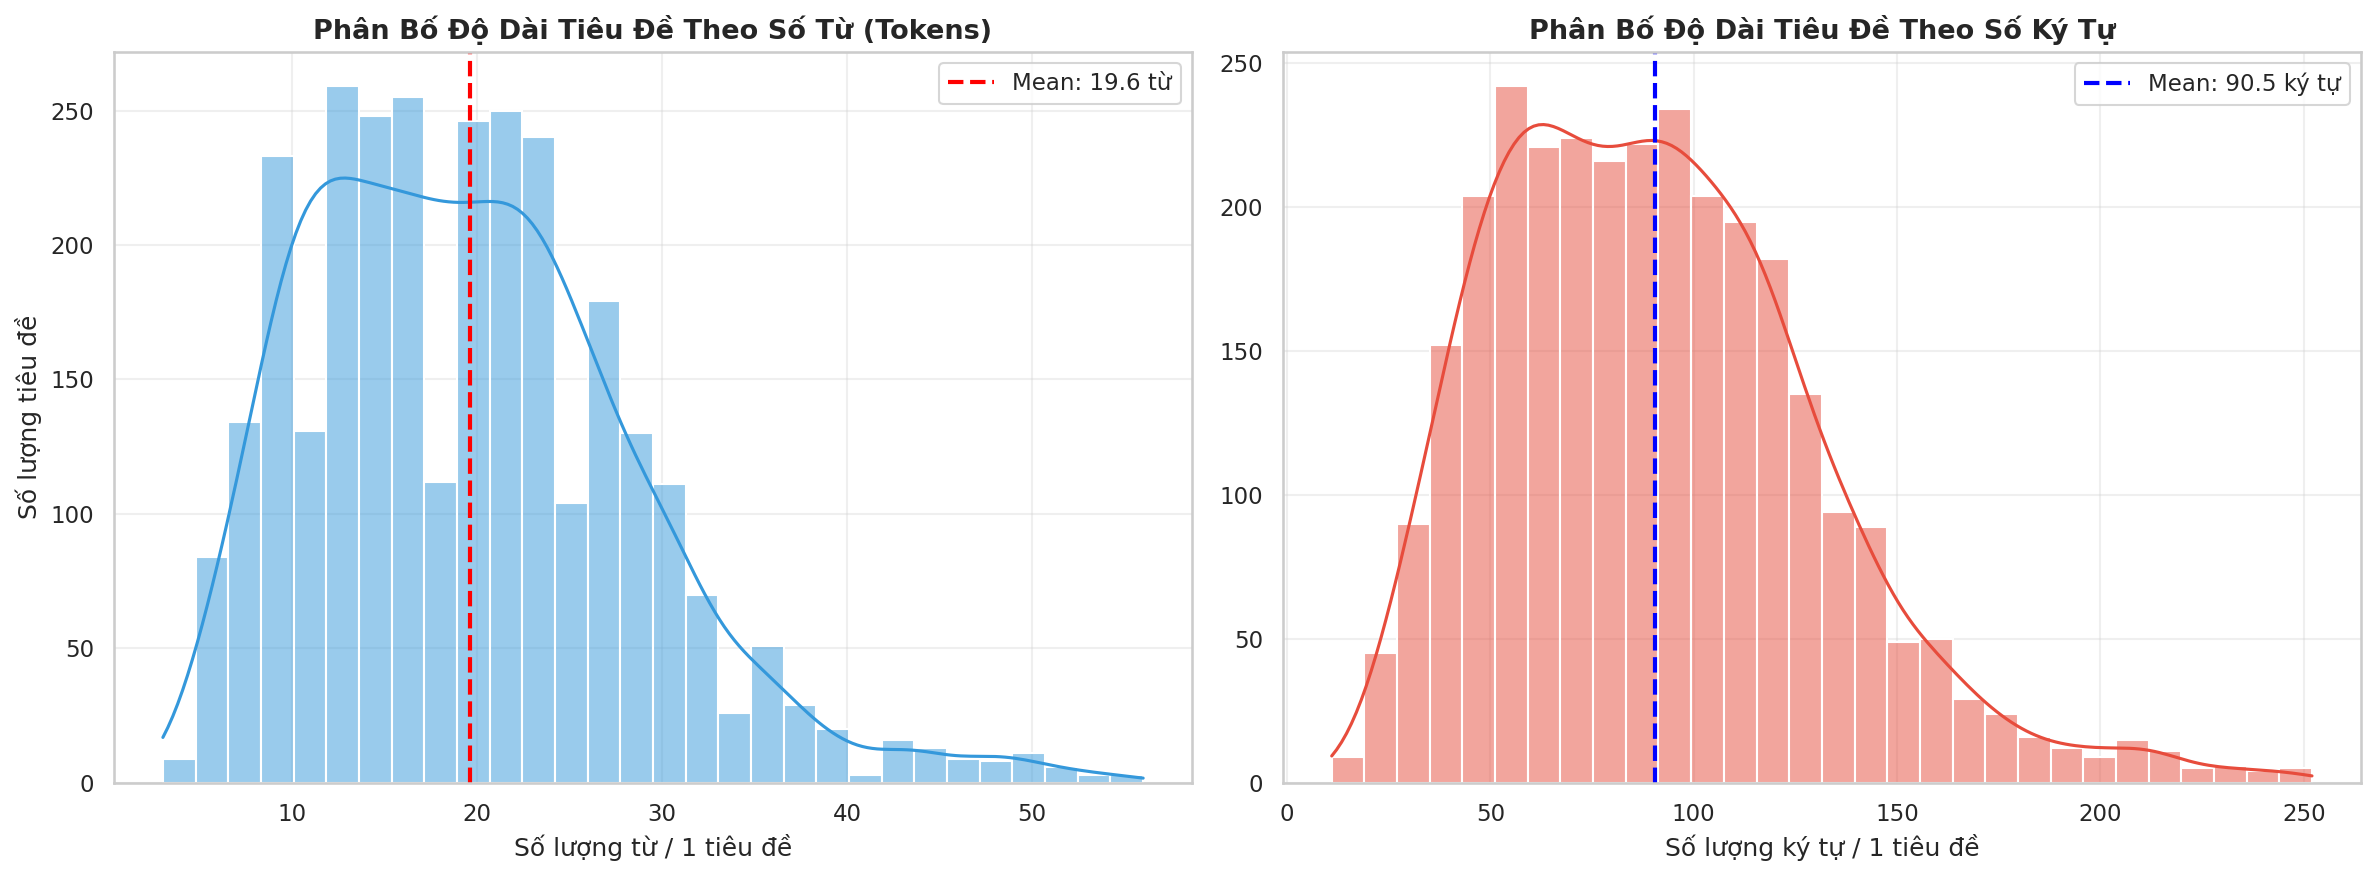

In [128]:
# BIỂU ĐỒ 1.1: HISTOGRAM - PHÂN BỐ ĐỘ DÀI TIÊU ĐỀ (WORD & CHAR)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(data=df_titles, x='word_count', bins=30, kde=True, color='#3498db', ax=axes[0])
axes[0].axvline(df_titles['word_count'].mean(), color='red', linestyle='--', linewidth=2,
                label=f"Mean: {df_titles['word_count'].mean():.1f} từ")
axes[0].set_title('Phân Bố Độ Dài Tiêu Đề Theo Số Từ (Tokens)', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Số lượng từ / 1 tiêu đề')
axes[0].set_ylabel('Số lượng tiêu đề')
axes[0].legend()

sns.histplot(data=df_titles, x='char_count', bins=30, kde=True, color='#e74c3c', ax=axes[1])
axes[1].axvline(df_titles['char_count'].mean(), color='blue', linestyle='--', linewidth=2,
                label=f"Mean: {df_titles['char_count'].mean():.1f} ký tự")
axes[1].set_title('Phân Bố Độ Dài Tiêu Đề Theo Số Ký Tự', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Số lượng ký tự / 1 tiêu đề')
axes[1].set_ylabel('')
axes[1].legend()

plt.tight_layout()
plt.savefig("1_1_Title_Length_Distribution.png", dpi=300)
plt.show()


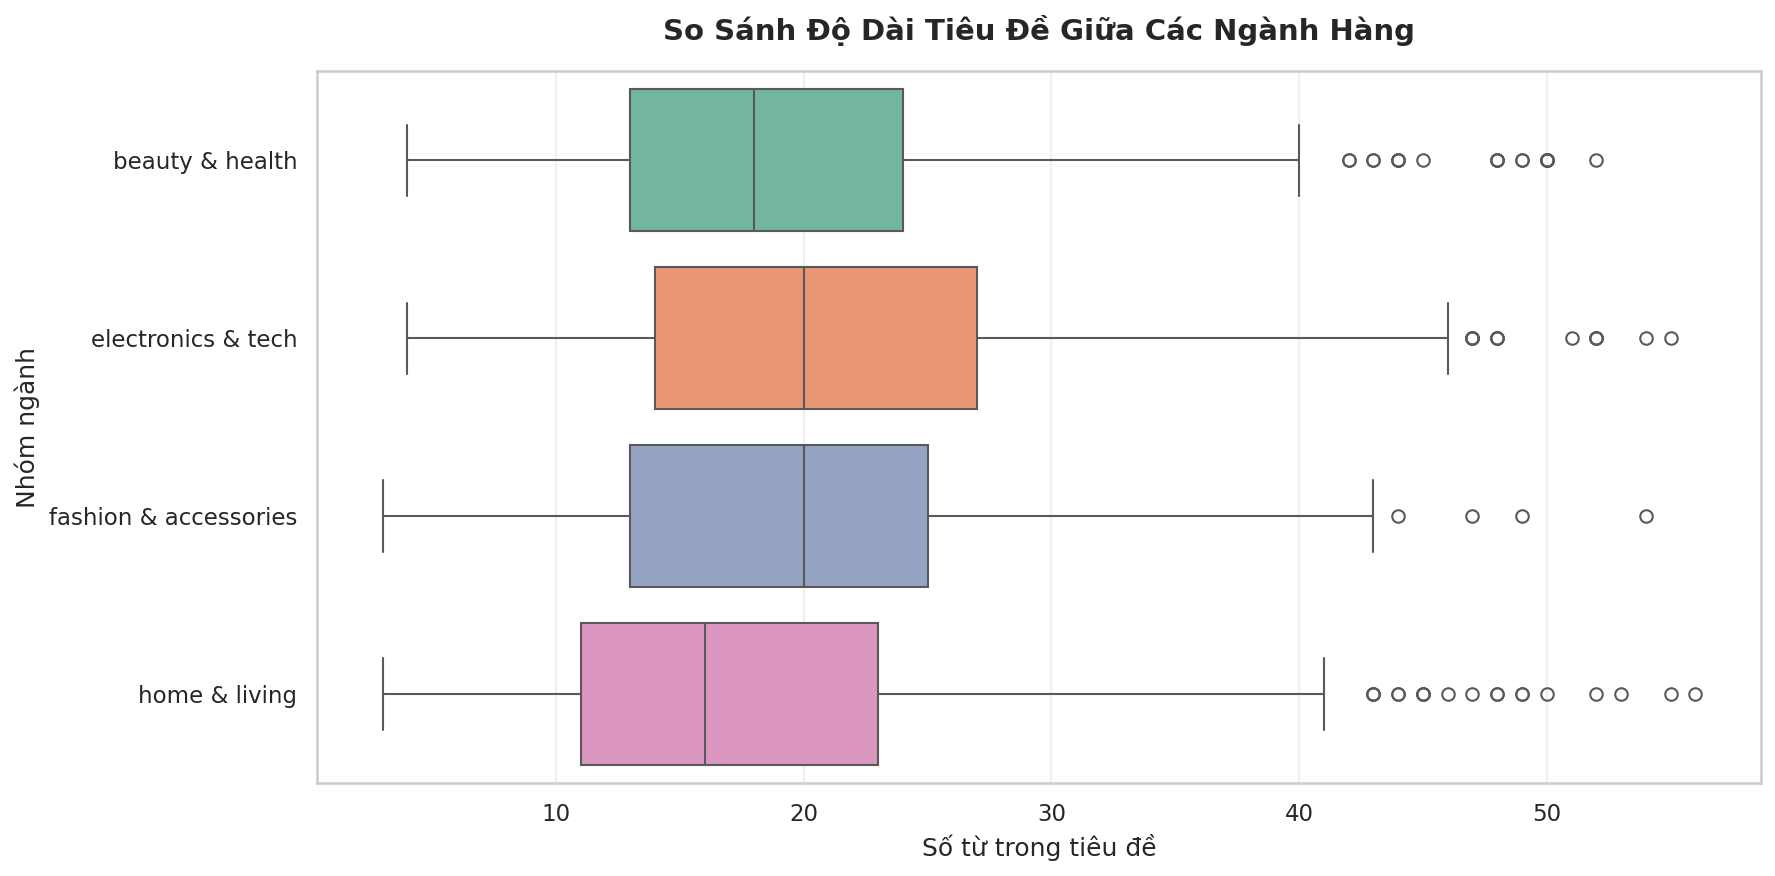

In [129]:
# BIỂU ĐỒ 1.2: BOXPLOT - SO SÁNH ĐỘ DÀI TIÊU ĐỀ THEO DOMAIN

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_titles, y='industry_group', x='word_count', palette='Set2',
            hue='industry_group', legend=False)

plt.title('So Sánh Độ Dài Tiêu Đề Giữa Các Ngành Hàng', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Số từ trong tiêu đề', fontsize=12)
plt.ylabel('Nhóm ngành', fontsize=12)
plt.tight_layout()
plt.savefig("1_2_Title_Length_Boxplot.png", dpi=300)
plt.show()


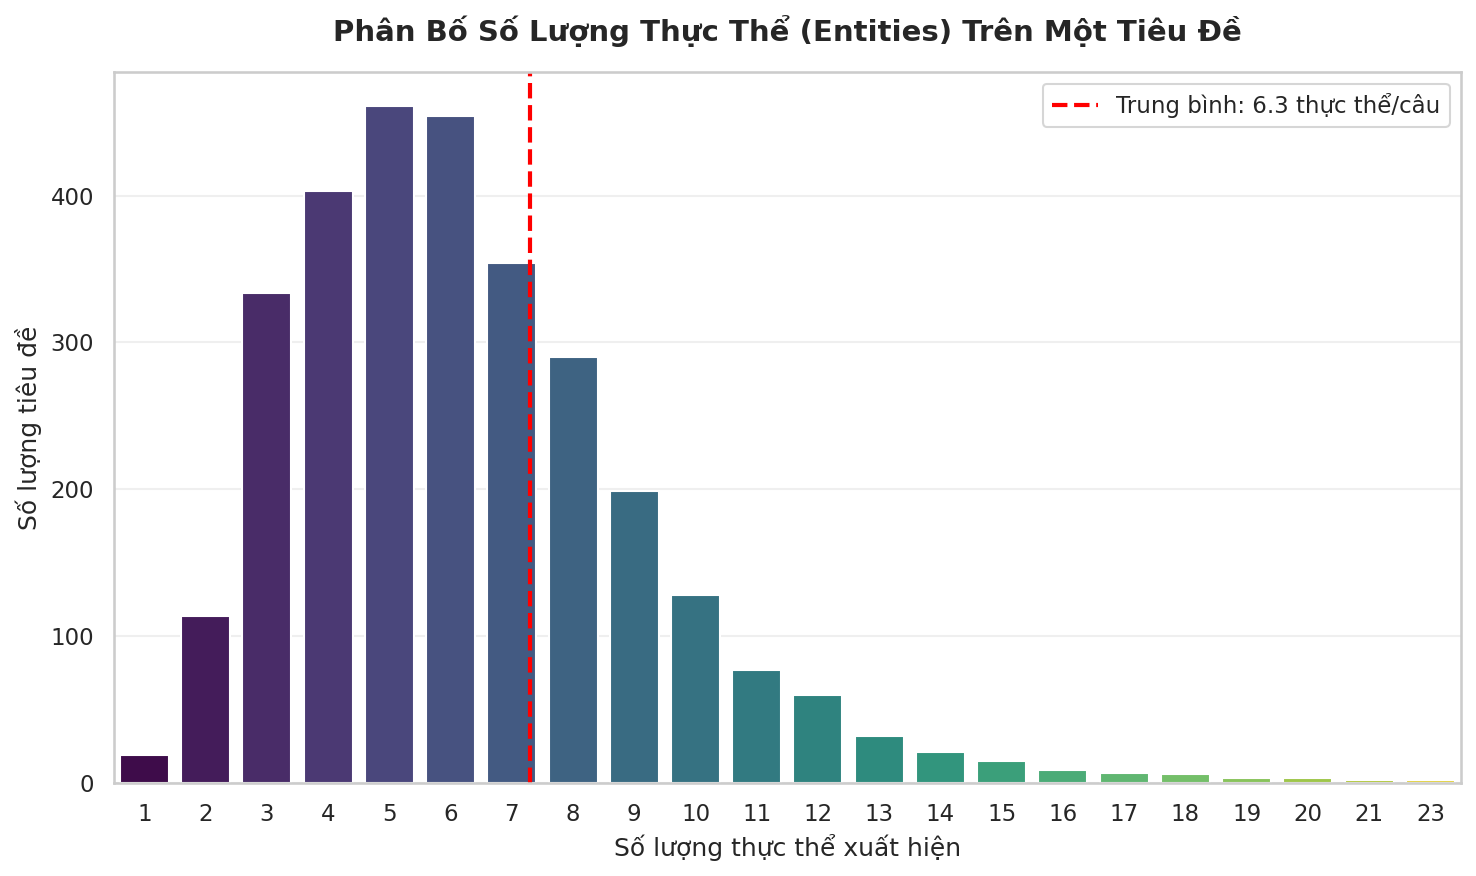

In [130]:
# BIỂU ĐỒ 1.3: HISTOGRAM - SỐ LƯỢNG ENTITY TRÊN 1 TIÊU ĐỀ

plt.figure(figsize=(10, 6))
sns.countplot(data=df_titles, x='entity_count', palette='viridis', hue='entity_count', legend=False)

mean_ent = df_titles['entity_count'].mean()
plt.axvline(mean_ent, color='red', linestyle='--', linewidth=2,
            label=f'Trung bình: {mean_ent:.1f} thực thể/câu')

plt.title('Phân Bố Số Lượng Thực Thể (Entities) Trên Một Tiêu Đề', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Số lượng thực thể xuất hiện', fontsize=12)
plt.ylabel('Số lượng tiêu đề', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig("1_3_Entity_Count_Distribution.png", dpi=300)
plt.show()


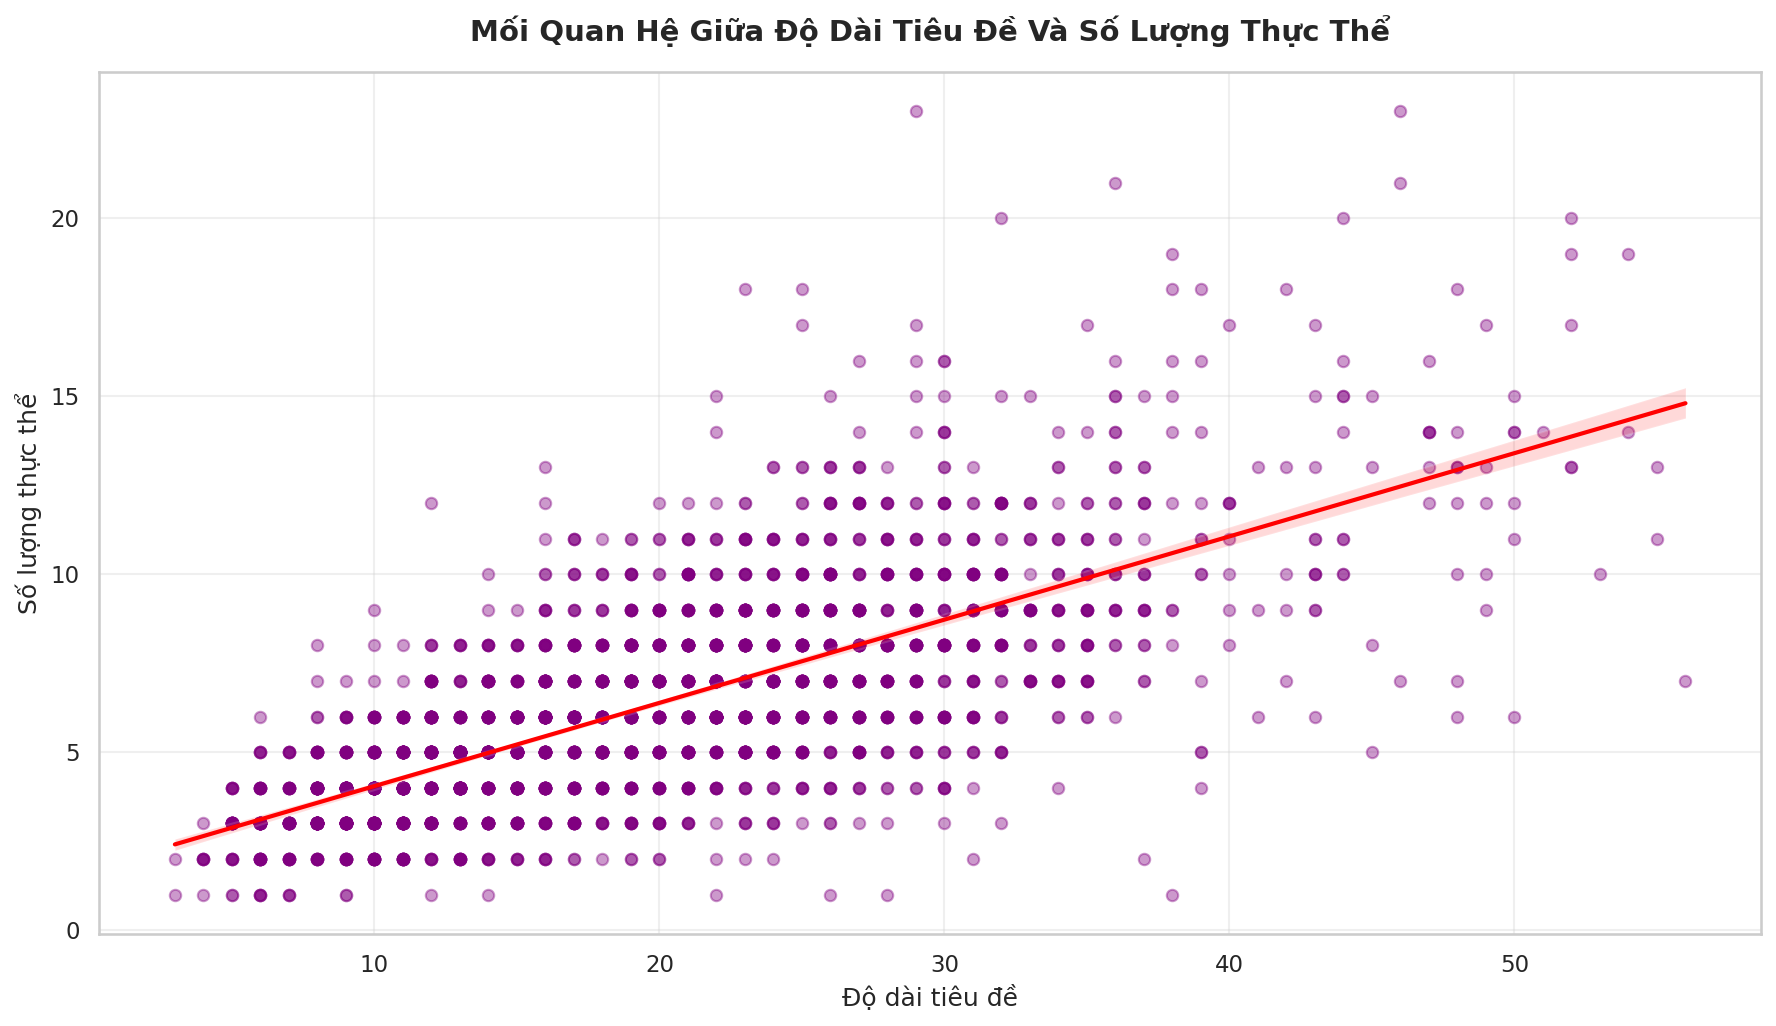

In [131]:
# BIỂU ĐỒ 1.4: SCATTER + REGRESSION - MỐI QUAN HỆ ĐỘ DÀI vs SỐ THỰC THỂ

plt.figure(figsize=(12, 7))

sns.regplot(data=df_titles, x='word_count', y='entity_count',
            scatter_kws={'alpha': 0.4, 'color': 'purple', 's': 30},
            line_kws={'color': 'red', 'linewidth': 2})

plt.title('Mối Quan Hệ Giữa Độ Dài Tiêu Đề Và Số Lượng Thực Thể',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Độ dài tiêu đề', fontsize=12)
plt.ylabel('Số lượng thực thể', fontsize=12)

plt.tight_layout()
plt.savefig("1_4_Entity_Density_Trend.png", dpi=300)
plt.show()


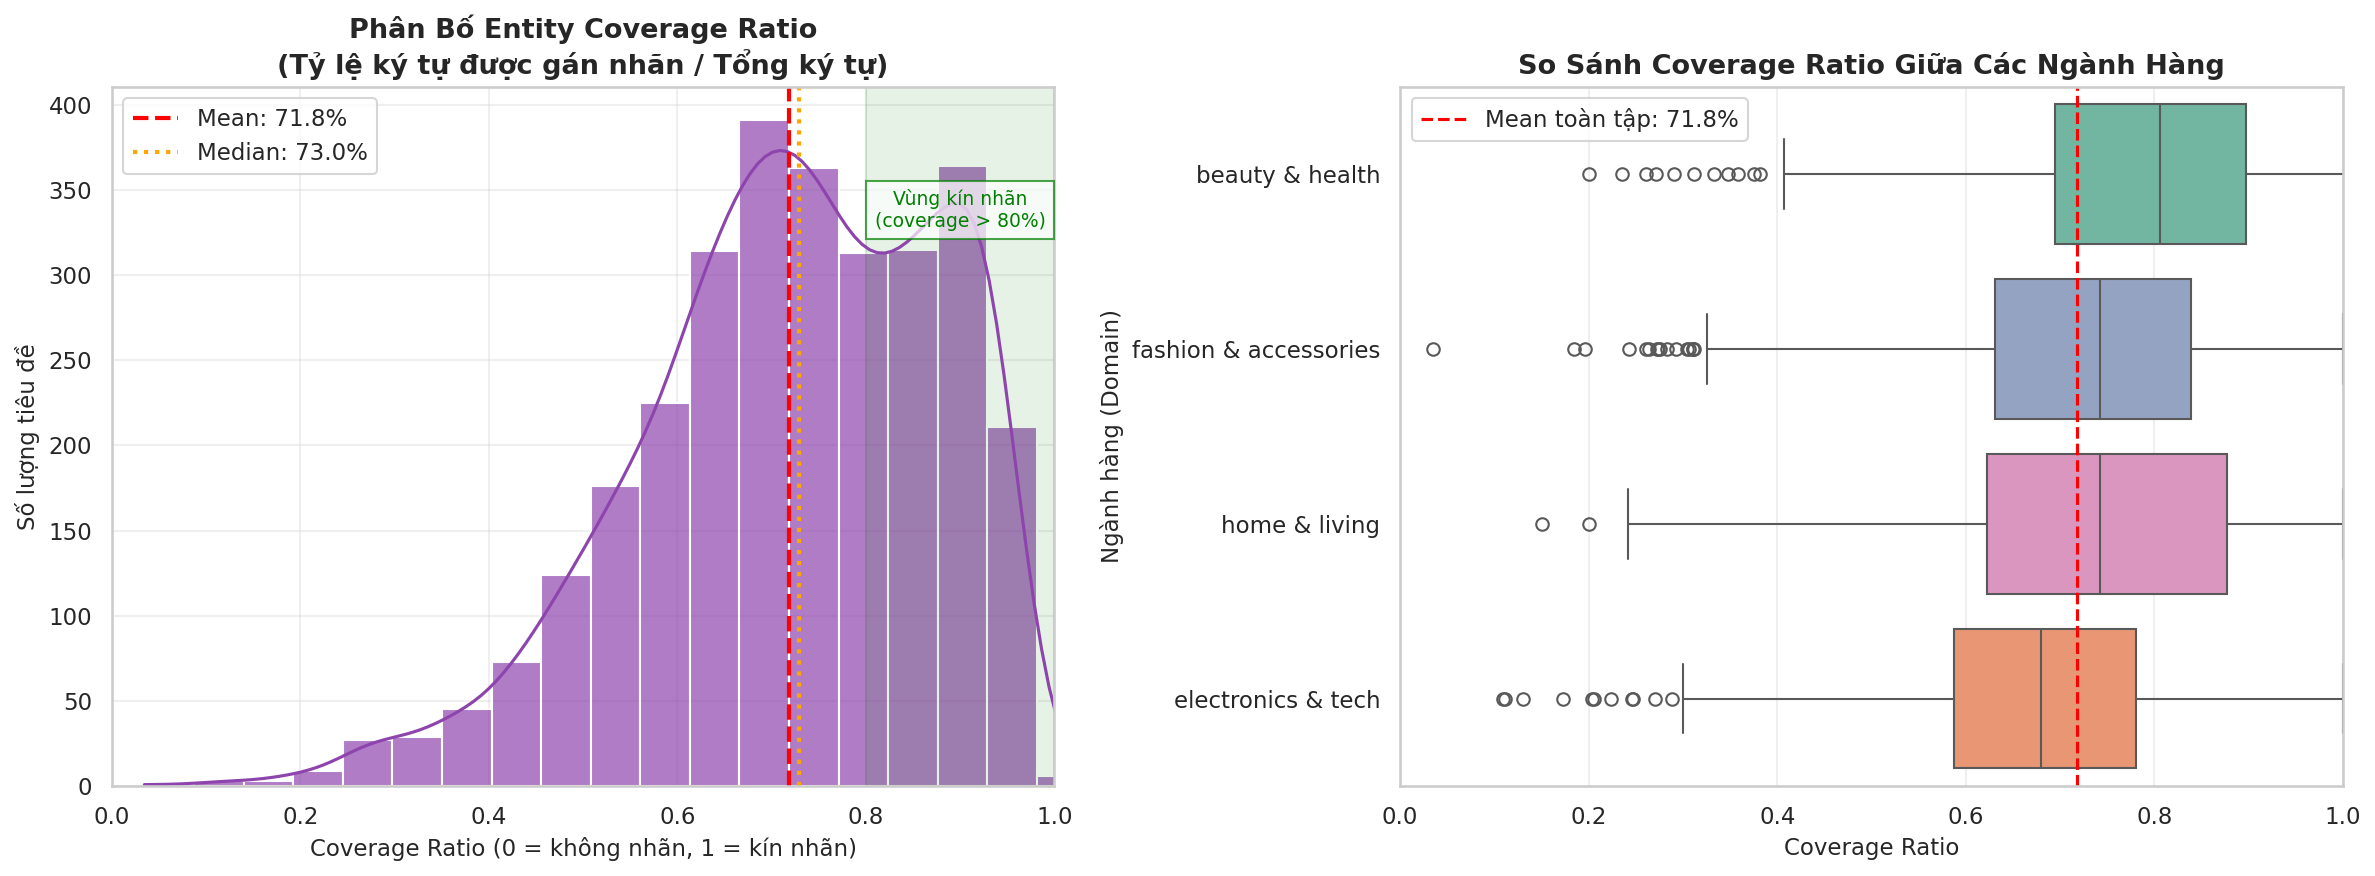

=== THỐNG KÊ COVERAGE RATIO ===
count    2993.000
mean        0.718
std         0.161
min         0.034
25%         0.620
50%         0.730
75%         0.851
max         1.613
Name: coverage_ratio, dtype: float64

=== COVERAGE RATIO TRUNG BÌNH THEO NGÀNH ===
industry_group
beauty & health          0.776
home & living            0.728
fashion & accessories    0.718
electronics & tech       0.676
Name: coverage_ratio, dtype: float64


In [132]:

# BIỂU ĐỒ 1.5: ENTITY COVERAGE RATIO (Tỷ lệ ký tự được gán nhãn / Tổng ký tự)

df['span_len'] = df['end_char'] - df['start_char']

labeled_chars_per_title = (
    df[df['label'] != 'O']
    .groupby('id')['span_len']
    .sum()
    .reset_index(name='labeled_chars')
)

df_titles = df_titles.merge(labeled_chars_per_title, on='id', how='left')
df_titles['labeled_chars'] = df_titles['labeled_chars'].fillna(0)
df_titles['coverage_ratio'] = df_titles['labeled_chars'] / df_titles['char_count']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Subplot trái: Histogram tổng thể ---
mean_cov = df_titles['coverage_ratio'].mean()
median_cov = df_titles['coverage_ratio'].median()

sns.histplot(data=df_titles, x='coverage_ratio', bins=30, kde=True,
             color='#8e44ad', ax=axes[0], alpha=0.7)
axes[0].axvline(mean_cov, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_cov:.1%}')
axes[0].axvline(median_cov, color='orange', linestyle=':', linewidth=2, label=f'Median: {median_cov:.1%}')
axes[0].set_title('Phân Bố Entity Coverage Ratio\n(Tỷ lệ ký tự được gán nhãn / Tổng ký tự)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Coverage Ratio (0 = không nhãn, 1 = kín nhãn)', fontsize=11)
axes[0].set_ylabel('Số lượng tiêu đề', fontsize=11)
axes[0].set_xlim(0, 1)
axes[0].legend()

axes[0].axvspan(0.8, 1.0, alpha=0.1, color='green', label='Vùng kín nhãn (>80%)')
axes[0].annotate('Vùng kín nhãn\n(coverage > 80%)',
                 xy=(0.9, axes[0].get_ylim()[1] * 0.8),
                 fontsize=9, color='green', ha='center',
                 bbox=dict(facecolor='white', alpha=0.7, edgecolor='green'))

# --- Subplot phải: Boxplot theo Industry ---
order_cov = df_titles.groupby('industry_group')['coverage_ratio'].median().sort_values(ascending=False).index

sns.boxplot(data=df_titles, y='industry_group', x='coverage_ratio',
            palette='Set2', hue='industry_group', legend=False,
            order=order_cov, ax=axes[1])
axes[1].axvline(mean_cov, color='red', linestyle='--', linewidth=1.5, label=f'Mean toàn tập: {mean_cov:.1%}')
axes[1].set_title('So Sánh Coverage Ratio Giữa Các Ngành Hàng', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Coverage Ratio', fontsize=11)
axes[1].set_ylabel('Ngành hàng (Domain)', fontsize=11)
axes[1].set_xlim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.savefig('1_5_Entity_Coverage_Ratio.png', dpi=300)
plt.show()

print("=== THỐNG KÊ COVERAGE RATIO ===")
print(df_titles['coverage_ratio'].describe().round(3))
print()
print("=== COVERAGE RATIO TRUNG BÌNH THEO NGÀNH ===")
print(df_titles.groupby('industry_group')['coverage_ratio'].mean().round(3).sort_values(ascending=False))


**Nhận xét:**

- **Biểu đồ 1.1 (Histogram độ dài):** Tiêu đề TMĐT phân phối chuẩn lệch phải, tập trung đông đảo ở mức 15–20 từ và chạm gần giới hạn 255 ký tự của sàn.
- **Biểu đồ 1.2 (Boxplot theo Domain):** Ngành Điện tử & Công nghệ (Electronics & Tech) có phổ phân bố rộng nhất và chứa nhiều outlier tiêu đề siêu dài do đặc thù chứa nhiều thông số kỹ thuật (Spec/Model).
- **Biểu đồ 1.3 (Số lượng Entity/tiêu đề):** Khác với câu giao tiếp bình thường chỉ có 1–2 thực thể, câu TMĐT Việt Nam chứa trung bình khoảng 6 thực thể, tạo ra thách thức lớn về ranh giới (Boundary prediction) cho mô hình.
- **Biểu đồ 1.4 (Scatter + xu hướng):** Đường hồi quy đi lên rõ rệt, cho thấy tiêu đề càng dài thì số thực thể càng nhiều — phản ánh hành vi nhồi nhét từ khóa (keyword stuffing) hơn là thêm từ vựng ngữ pháp.
- **Biểu đồ 1.5 (Coverage Ratio):** Coverage trung bình ~72% — hơn 2/3 ký tự trong mỗi tiêu đề nằm trong một span thực thể. Khác với văn bản báo chí/văn học nơi thực thể là các "điểm đảo" thưa thớt, tiêu đề TMĐT Việt Nam là chuỗi thực thể liên tiếp gần như không có khoảng trắng ngữ nghĩa — khiến **boundary detection** trở thành thách thức cốt lõi, quan trọng hơn cả phân loại nhãn (label classification).


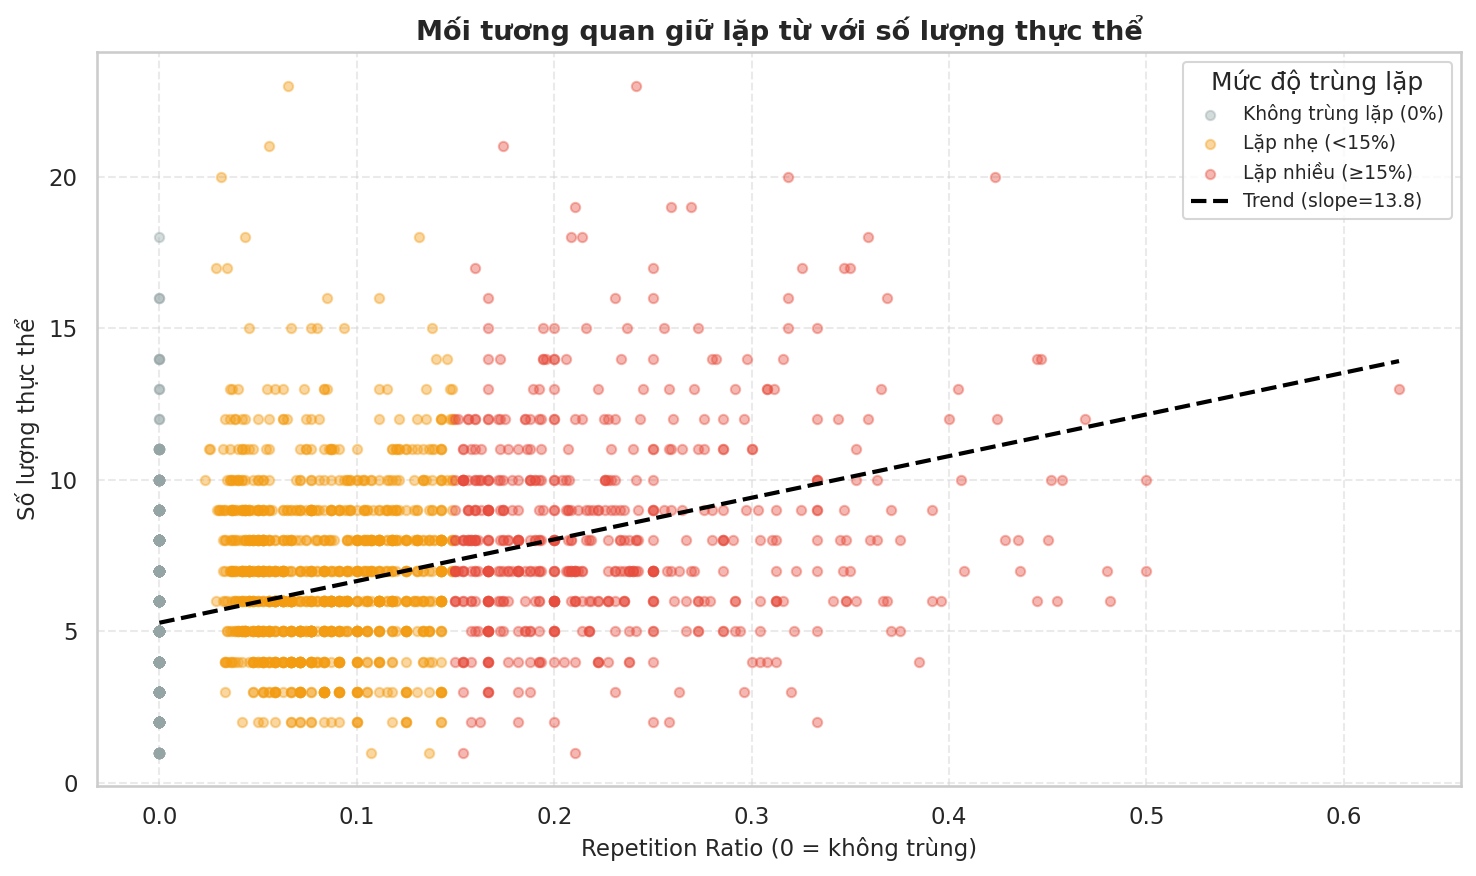

=== THỐNG KÊ MỨC ĐỘ TRÙNG LẶP ===
count    2993.000
mean        0.074
std         0.092
min         0.000
25%         0.000
50%         0.048
75%         0.118
max         0.628
Name: repetition_ratio, dtype: float64

=== PHÂN BỐ THEO NHÓM ===
  Không trùng lặp (0%): 1315 tiêu đề (43.9%)
  Lặp nhẹ (<15%): 1126 tiêu đề (37.6%)
  Lặp nhiều (≥15%): 552 tiêu đề (18.4%)

=== TƯƠNG QUAN VỚI SỐ LƯỢNG THỰC THỂ ===
  Pearson r = 0.432


In [133]:
# BIỂU ĐỒ 1.6: MỐI TƯƠNG QUAN GIỮA LẶP TỪ VÀ SỐ LƯỢNG THỰC THỂ

from collections import Counter

def calculate_repetition_ratio(text):
    if not isinstance(text, str) or not text.strip():
        return 0.0
    words = text.lower().split()
    if len(words) <= 1:
        return 0.0
    return 1 - (len(set(words)) / len(words))

df_titles['repetition_ratio'] = df_titles['full_text'].apply(calculate_repetition_ratio)



def label_repetition(r):
    if r == 0:      return 'Không trùng lặp (0%)'
    elif r < 0.15:  return 'Lặp nhẹ (<15%)'
    else:           return 'Lặp nhiều (≥15%)'

df_titles['rep_group'] = df_titles['repetition_ratio'].apply(label_repetition)

rep_order = ['Không trùng lặp (0%)', 'Lặp nhẹ (<15%)', 'Lặp nhiều (≥15%)']
rep_palette = {
    'Không trùng lặp (0%)': '#95a5a6',
    'Lặp nhẹ (<15%)':       '#f39c12',
    'Lặp nhiều (≥15%)':     '#e74c3c'
}

from numpy.polynomial.polynomial import polyfit

fig, ax = plt.subplots(figsize=(10, 6))

for group in rep_order:
    subset = df_titles[df_titles['rep_group'] == group]
    ax.scatter(subset['repetition_ratio'], subset['entity_count'],
               alpha=0.4, s=20, color=rep_palette[group], label=group)

x = df_titles['repetition_ratio'].values
y = df_titles['entity_count'].values
b, m = polyfit(x, y, 1)
x_line = sorted(x)
ax.plot(x_line, [b + m * xi for xi in x_line],
        color='black', linewidth=2, linestyle='--', label=f'Trend (slope={m:.1f})')

ax.set_title('Mối tương quan giữ lặp từ với số lượng thực thể', fontsize=13, fontweight='bold')
ax.set_xlabel('Repetition Ratio (0 = không trùng)', fontsize=11)
ax.set_ylabel('Số lượng thực thể', fontsize=11)
ax.legend(title='Mức độ trùng lặp', fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('1_4b_Repetition_vs_EntityCount.png', dpi=300)
plt.show()

# ── Thống kê mô tả ──
total = len(df_titles)
print("=== THỐNG KÊ MỨC ĐỘ TRÙNG LẶP ===")
print(df_titles['repetition_ratio'].describe().round(3))
print()
print("=== PHÂN BỐ THEO NHÓM ===")
for grp in rep_order:
    n = (df_titles['rep_group'] == grp).sum()
    print(f"  {grp}: {n} tiêu đề ({n/total*100:.1f}%)")
print()
print("=== TƯƠNG QUAN VỚI SỐ LƯỢNG THỰC THỂ ===")
corr = df_titles['repetition_ratio'].corr(df_titles['entity_count'])
print(f"  Pearson r = {corr:.3f}")

**Nhận xét:**

Phân tích lexical repetition cho thấy **43.9% tiêu đề không có bất kỳ từ nào bị lặp lại**, và thêm 37.6% chỉ lặp ở mức nhẹ (<15%). Tổng cộng hơn 80% dataset có mức độ trùng lặp từ thấp, phản ánh xu hướng viết tiêu đề súc tích, mỗi từ mang một vai trò ngữ nghĩa riêng biệt. Chỉ 18.5% tiêu đề (nhóm Lặp nhiều ≥15%) có dấu hiệu keyword stuffing thực sự, do người bán có xu hướng lặp lại tên thương hiệu, tên sản phẩm hoặc thuộc tính để tối ưu tìm kiếm.

---
## 2. Phân bố nhãn 

Phân tích sự mất cân bằng giữa các loại nhãn, kiểm tra tính đồng nhất giữa các tập Train/Dev/Test, sự khác biệt cấu trúc nhãn giữa các ngành hàng, tính đại diện của mẫu IAA, và mức độ đồng xuất hiện (co-occurrence) giữa các nhãn.

/tmp/ipykernel_58/3856748057.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(data=label_counts, y='label', x='count', palette=colors)


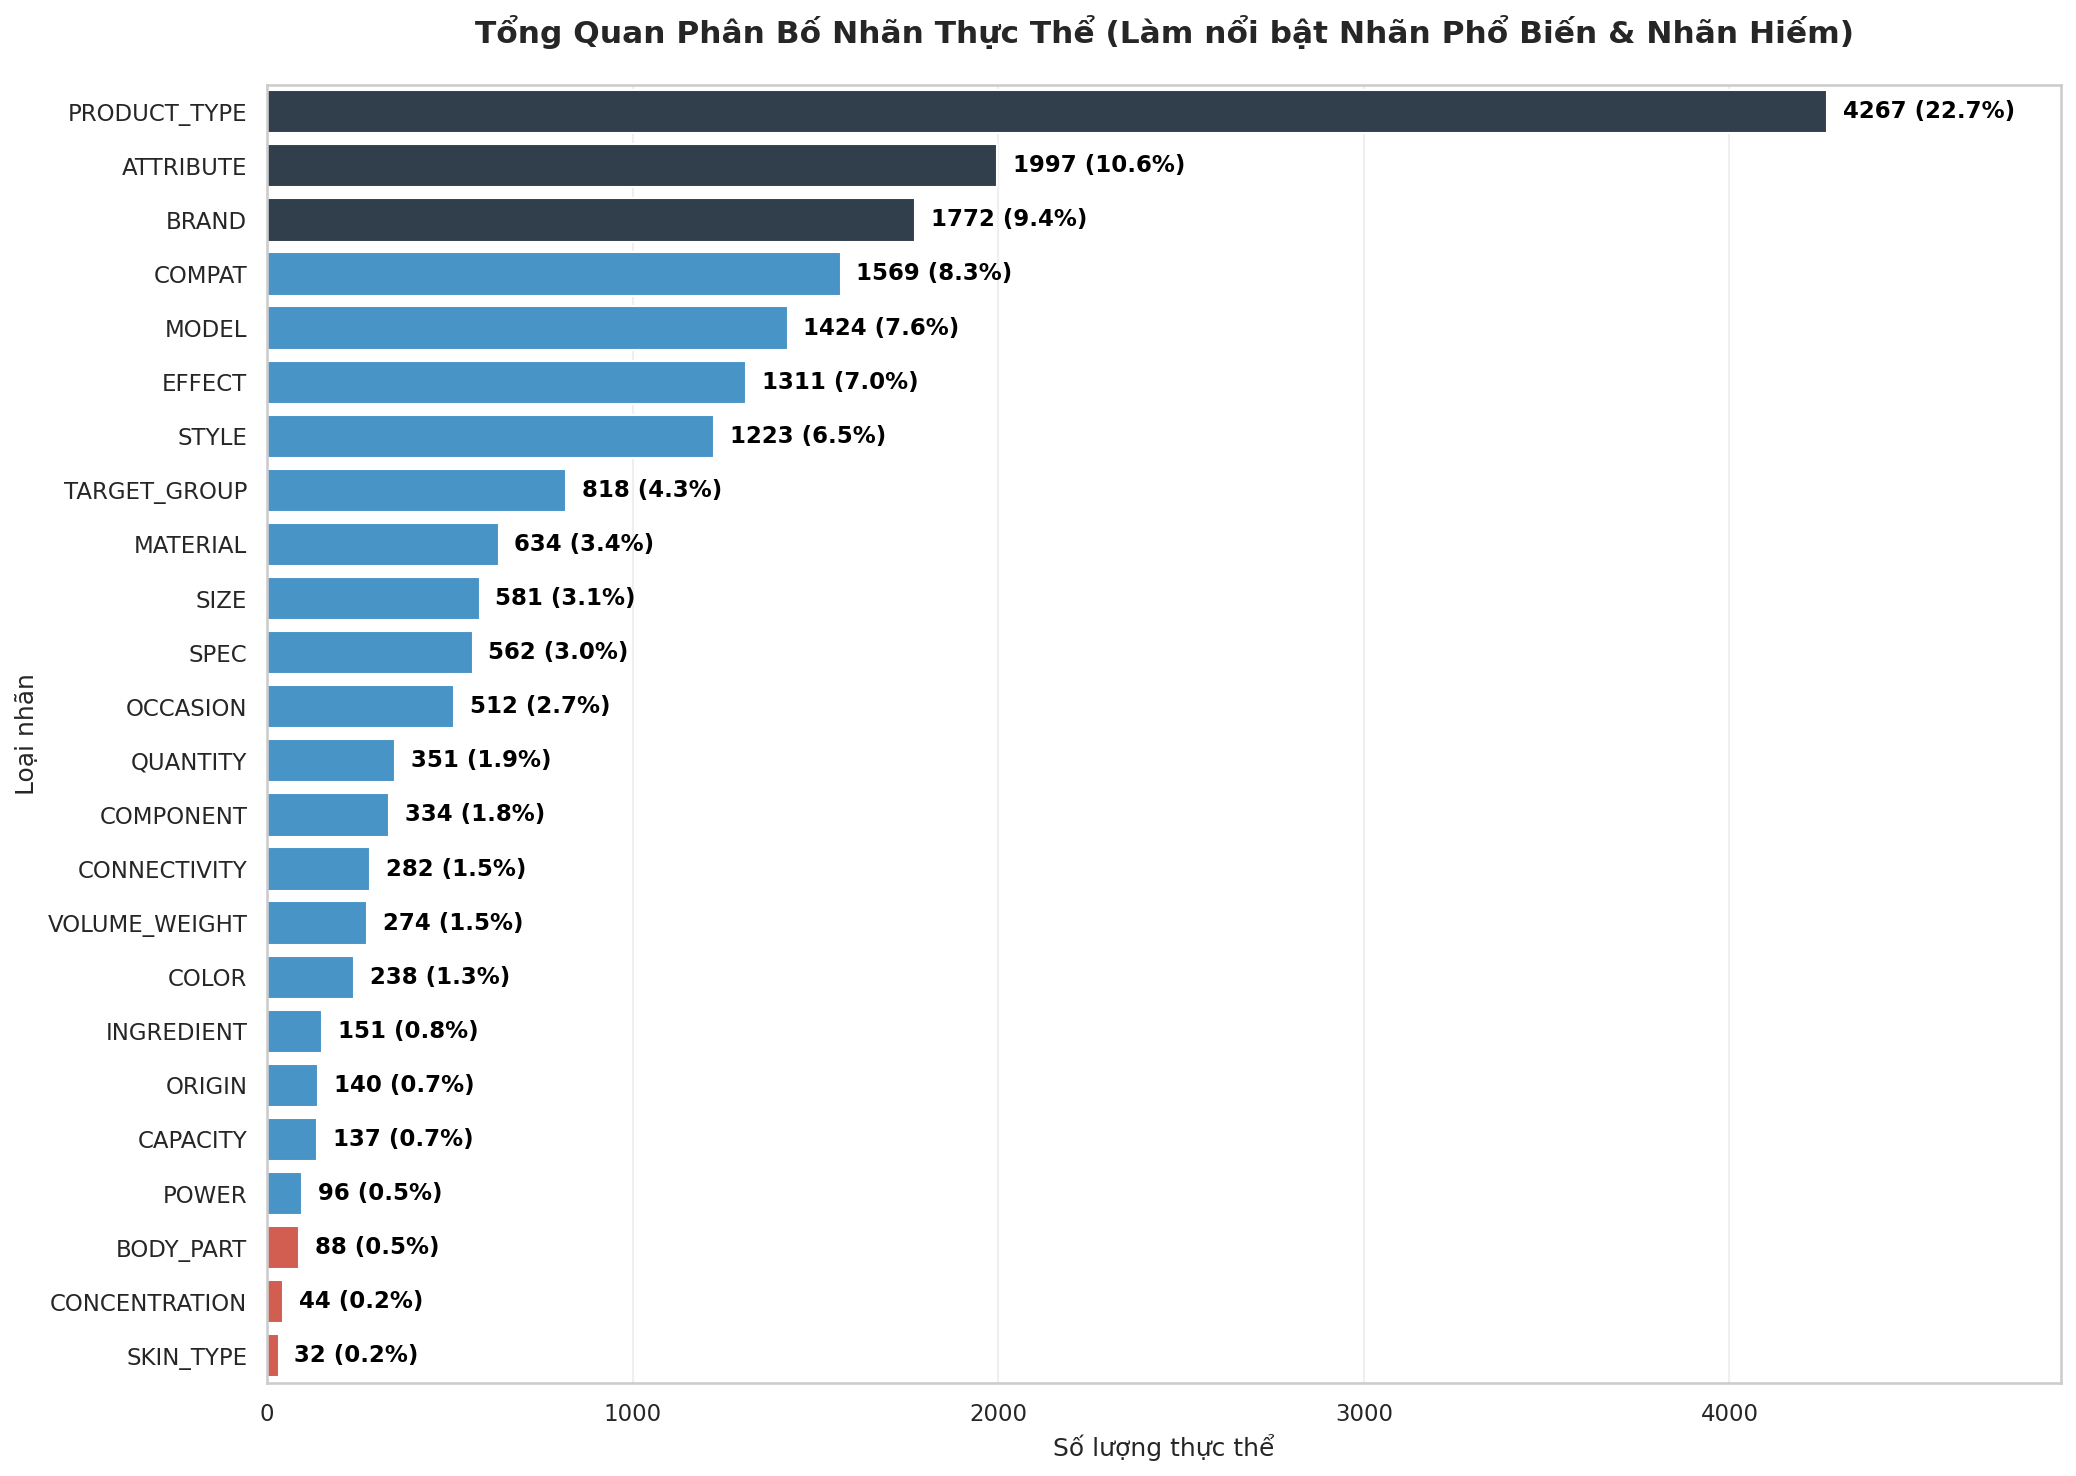

In [134]:
# BIỂU ĐỒ 2.1: TỔNG QUAN PHÂN BỐ NHÃN 

plt.figure(figsize=(14, 10))

label_counts = df_ent['label'].value_counts().reset_index()
label_counts.columns = ['label', 'count']
total_ent = label_counts['count'].sum()
label_counts['percent'] = (label_counts['count'] / total_ent) * 100

# Phân loại màu: Top 3 (xanh đậm) - Khác (xanh nhạt) - Bottom 3 (đỏ, nhãn hiếm)
colors = ['#2c3e50'] * 3 + ['#3498db'] * (len(label_counts) - 6) + ['#e74c3c'] * 3

ax1 = sns.barplot(data=label_counts, y='label', x='count', palette=colors)

for p in ax1.patches:
    width = p.get_width()
    pct = (width / total_ent) * 100
    ax1.text(width + (label_counts['count'].max() * 0.01),
             p.get_y() + p.get_height() / 2,
             f'{int(width)} ({pct:.1f}%)',
             va='center', fontsize=11, fontweight='bold', color='black')

plt.title('Tổng Quan Phân Bố Nhãn Thực Thể (Làm nổi bật Nhãn Phổ Biến & Nhãn Hiếm)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Số lượng thực thể', fontsize=12)
plt.ylabel('Loại nhãn', fontsize=12)
plt.xlim(0, label_counts['count'].max() * 1.15)
plt.tight_layout()
plt.savefig("2_1_Overall_Label_Distribution.png", dpi=300)
plt.show()

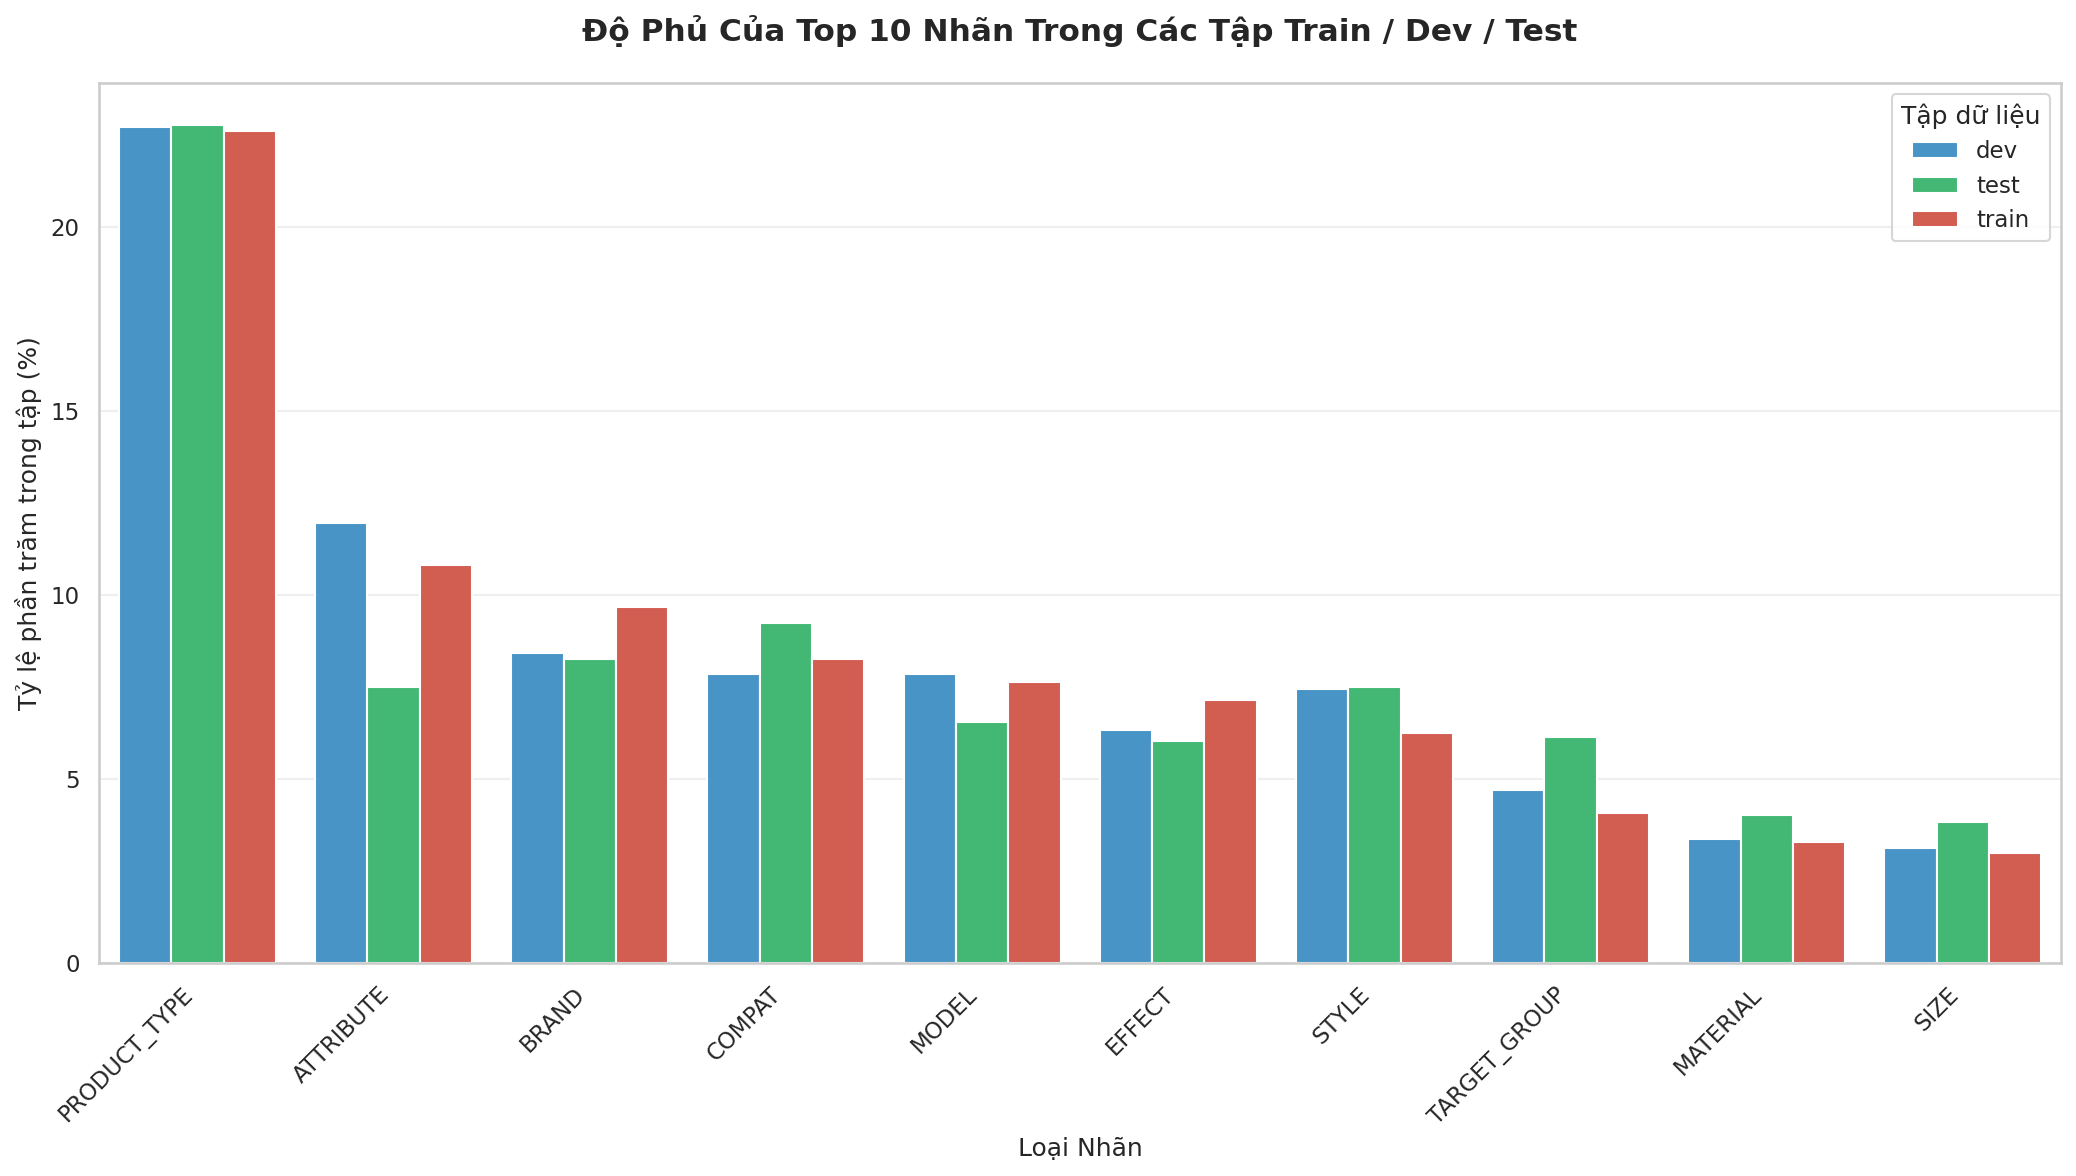

In [135]:
# BIỂU ĐỒ 2.2: SO SÁNH PHÂN BỐ NHÃN GIỮA TRAIN / DEV / TEST

plt.figure(figsize=(14, 8))

split_cross = pd.crosstab(df_ent['label'], df_ent['split'], normalize='columns') * 100

top_10_labels = label_counts['label'].head(10).tolist()
split_cross_top10 = split_cross.loc[top_10_labels]

split_melted = split_cross_top10.reset_index().melt(id_vars='label', var_name='split', value_name='percentage')

sns.barplot(data=split_melted, x='label', y='percentage', hue='split', palette=['#3498db', '#2ecc71', '#e74c3c'])
plt.title('Độ Phủ Của Top 10 Nhãn Trong Các Tập Train / Dev / Test', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Loại Nhãn', fontsize=12)
plt.ylabel('Tỷ lệ phần trăm trong tập (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Tập dữ liệu')
plt.tight_layout()
plt.savefig("2_2_Train_Dev_Test_Split.png", dpi=300)
plt.show()

<Figure size 1800x1200 with 0 Axes>

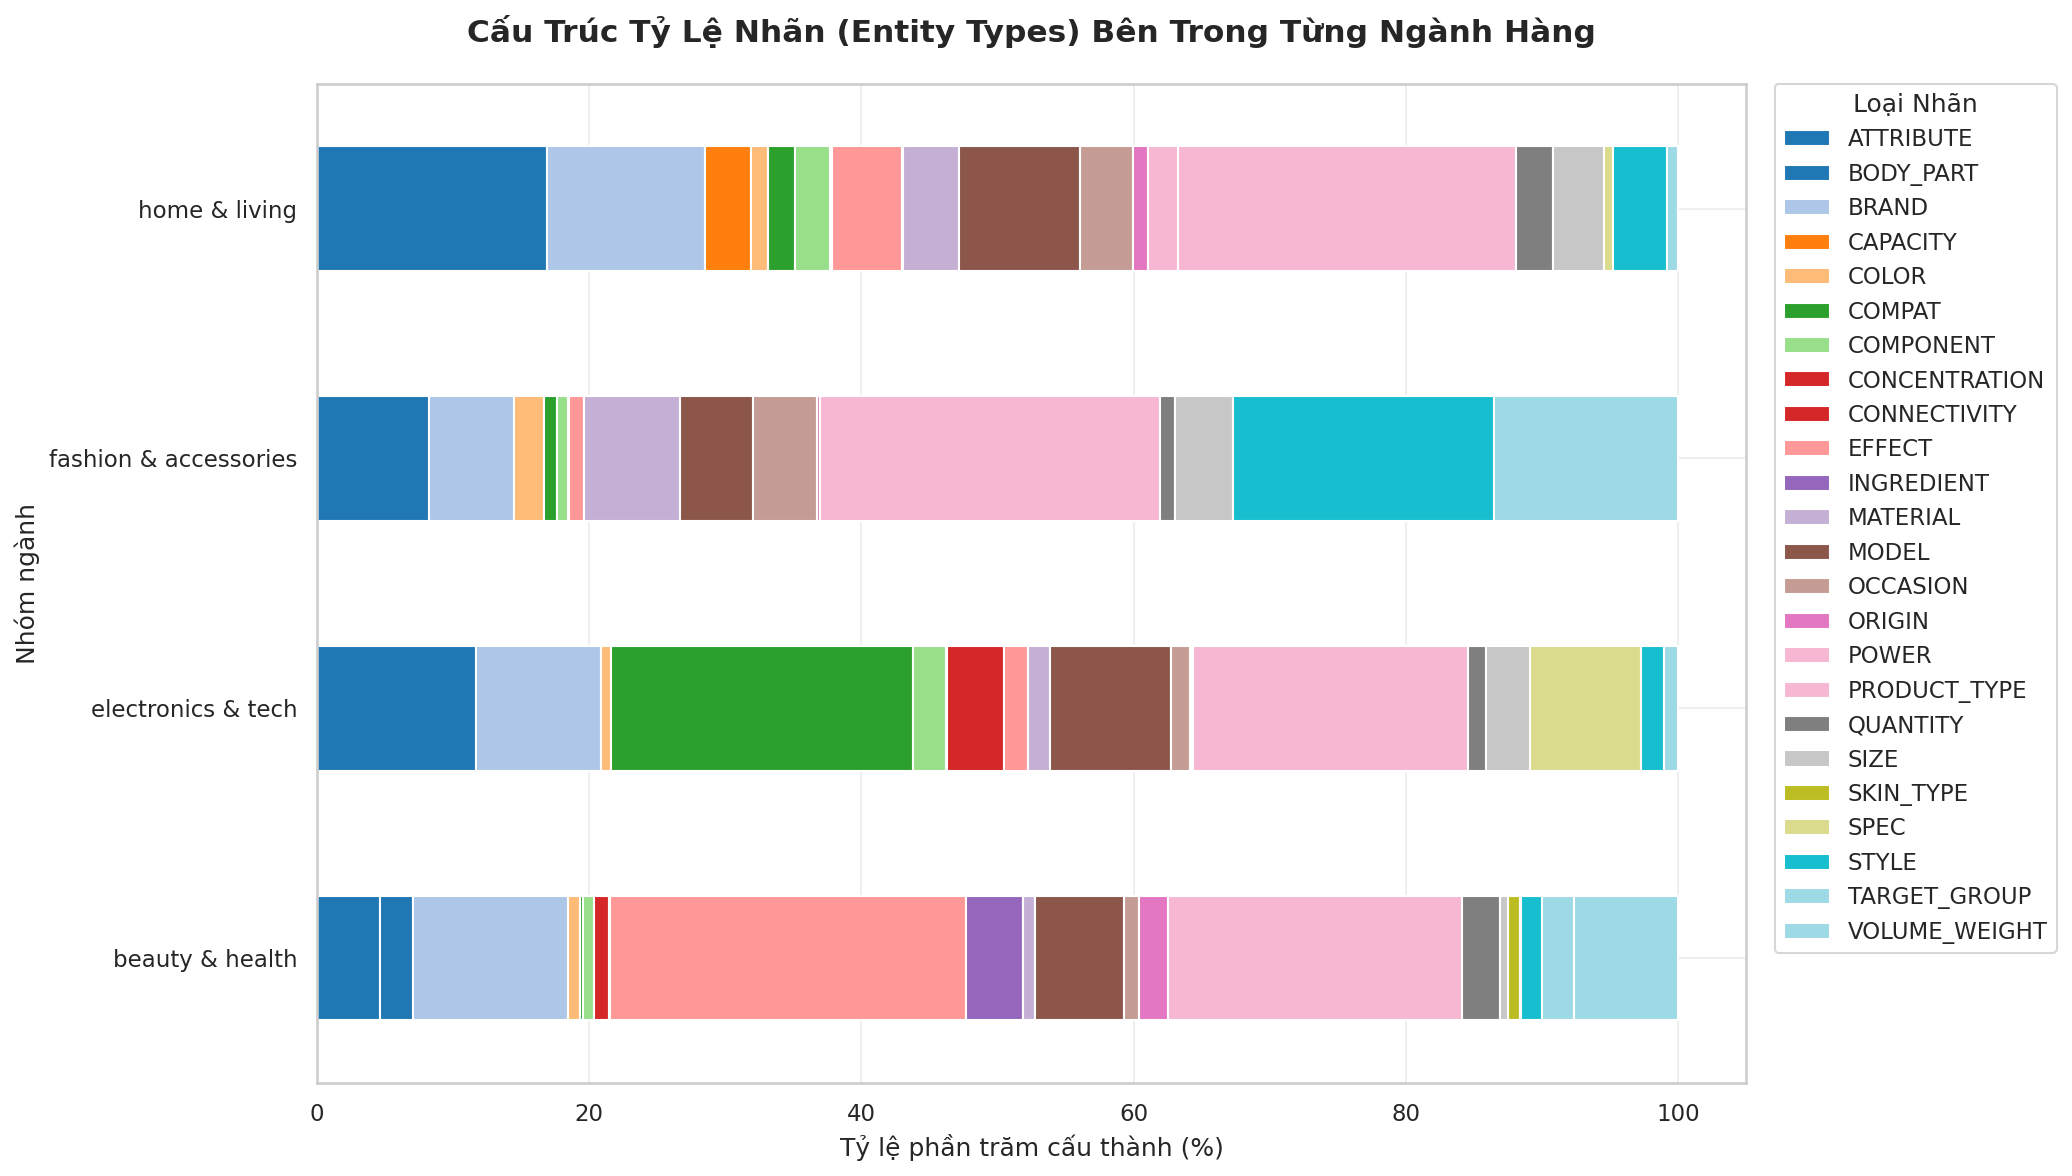

In [136]:
# BIỂU ĐỒ 2.3: PHÂN BỐ NHÃN THEO NGÀNH HÀNG 

plt.figure(figsize=(12, 8))

domain_cross = pd.crosstab(df_ent['industry_group'], df_ent['label'], normalize='index') * 100

domain_cross.plot(kind='barh', stacked=True, figsize=(14, 8), colormap='tab20', edgecolor='white')

plt.title('Cấu Trúc Tỷ Lệ Nhãn (Entity Types) Bên Trong Từng Ngành Hàng', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Tỷ lệ phần trăm cấu thành (%)', fontsize=12)
plt.ylabel('Nhóm ngành', fontsize=12)
plt.legend(title='Loại Nhãn', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.savefig("2_3_Domain_Label_Distribution.png", dpi=300)
plt.show()

**Nhận xét (Biểu đồ 2.1 – 2.3):**

- **Biểu đồ 2.1 (Overall):** Sự phân bố của các nhãn tuân theo quy luật đuôi dài. `PRODUCT_TYPE` và `BRAND` chiếm áp đảo do là nhãn dùng chung cho mọi domain, trong khi các nhãn ít và hiếm như `SKIN_TYPE` hay `CONCENTRATION` chỉ chiếm dưới 0.5% do là nhãn riêng cho ngành Beauty. Sự mất cân bằng này phản ánh đúng thực tế TMĐT, buộc quá trình huấn luyện mô hình phải dùng các hàm loss chuyên dụng (như Focal Loss) hoặc Class Weights để không bỏ sót nhãn thiểu số.
- **Biểu đồ 2.2 (Train/Dev/Test):** Phân phối của top 10 nhãn cốt lõi gần như đồng nhất giữa 3 tập — đảm bảo mô hình không bị thiên lệch trong huấn luyện và đánh giá trên tập Test phản ánh đúng năng lực thực tế.
- **Biểu đồ 2.3 (Domain Stacked):** Cấu trúc thực thể biến đổi hoàn toàn theo ngành. Điện tử (Electronics) bị lấp đầy bởi `MODEL` và `SPEC`, trong khi Mỹ phẩm (Beauty & Health) đặc trưng bởi `EFFECT` và `TARGET_GROUP`. Mô hình NER không thể học vẹt theo từ điển mà phải có khả năng hiểu ngữ cảnh chéo ngành.


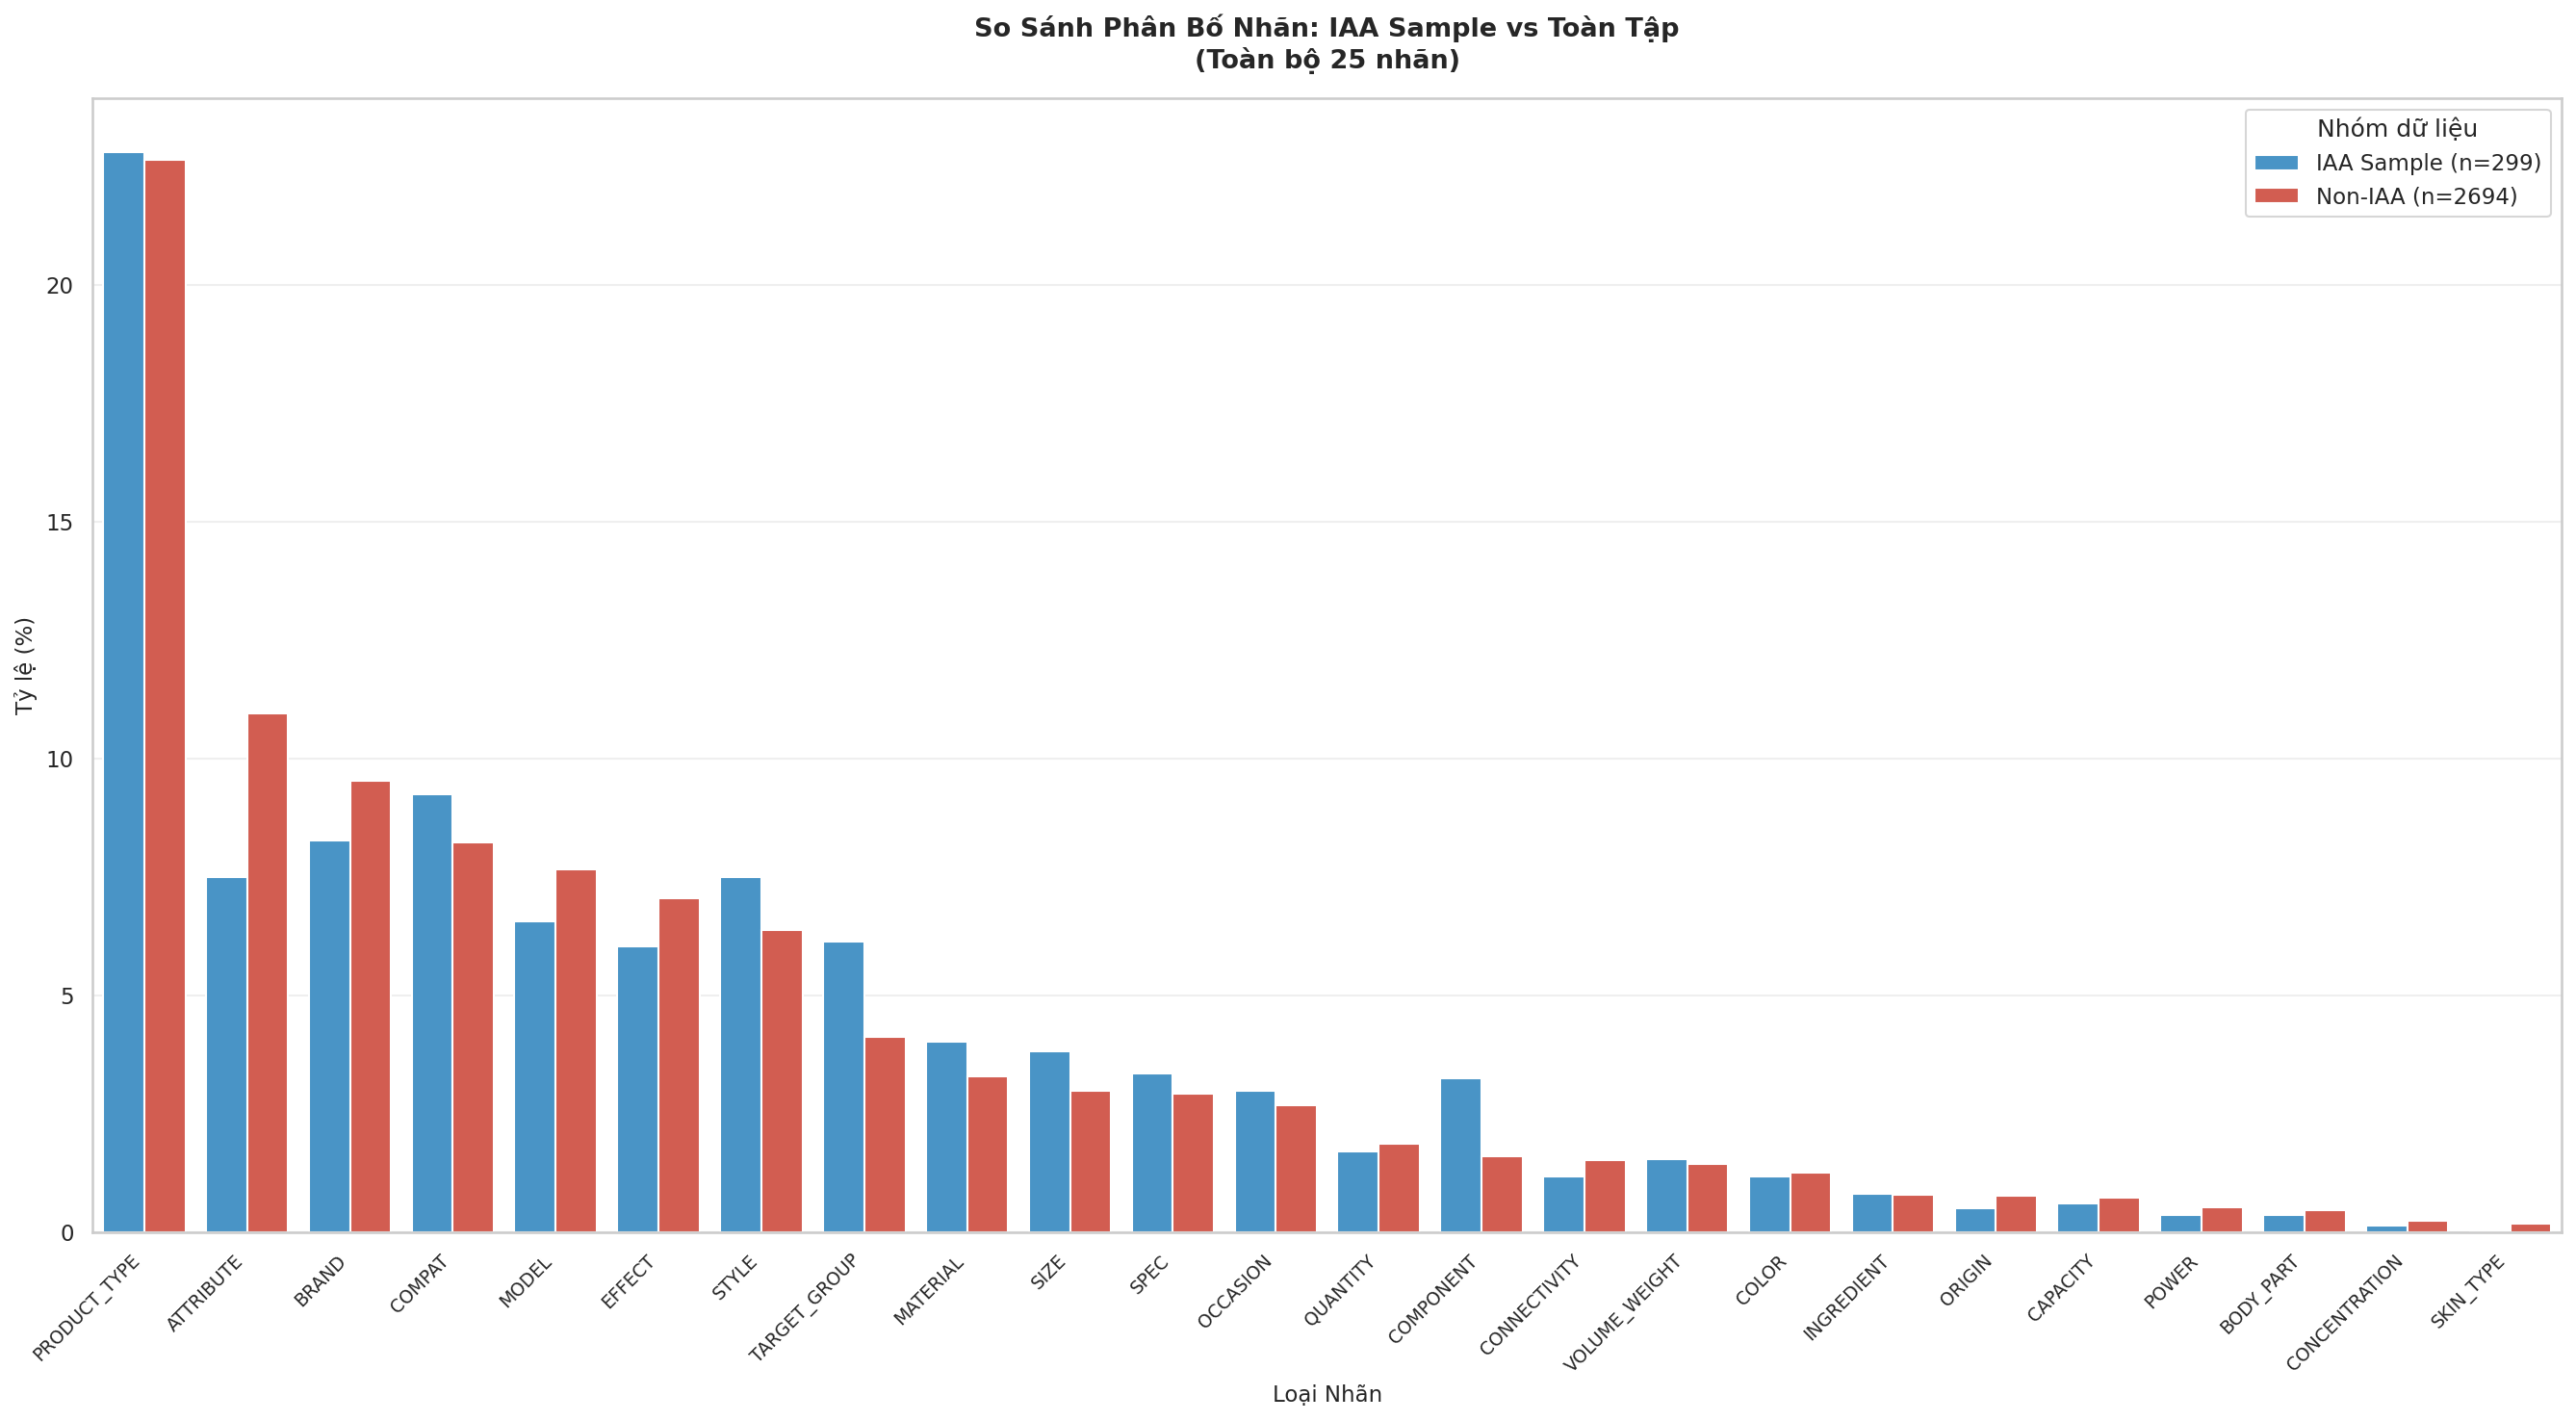

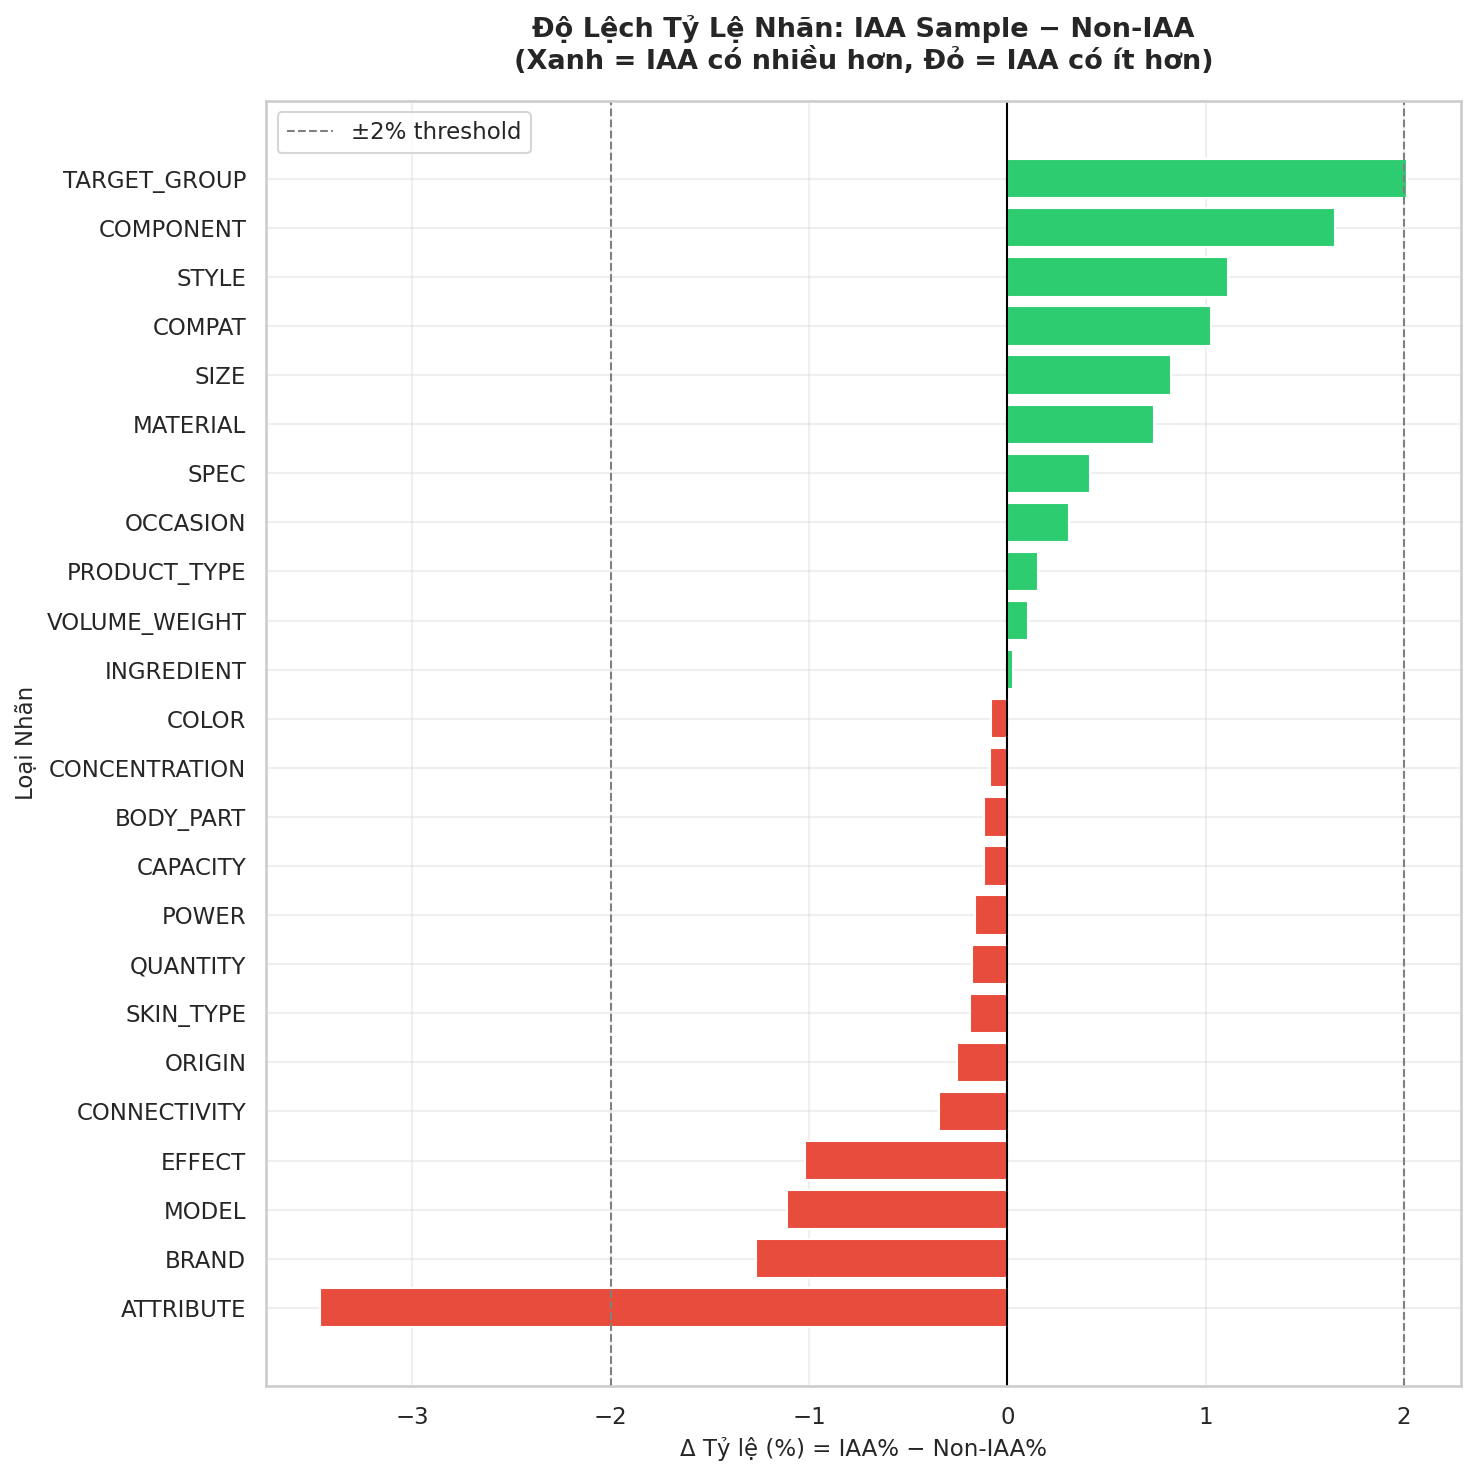

=== KIỂM ĐỊNH TÍNH ĐẠI DIỆN CỦA IAA SAMPLE ===
Độ lệch tỷ lệ nhãn (IAA% - Non-IAA%):
label
ATTRIBUTE       -3.46
BRAND           -1.27
MODEL           -1.11
EFFECT          -1.02
CONNECTIVITY    -0.34
ORIGIN          -0.25
SKIN_TYPE       -0.19
QUANTITY        -0.18
POWER           -0.16
CAPACITY        -0.12
BODY_PART       -0.12
CONCENTRATION   -0.09
COLOR           -0.08
INGREDIENT       0.03
VOLUME_WEIGHT    0.11
PRODUCT_TYPE     0.15
OCCASION         0.31
SPEC             0.42
MATERIAL         0.74
SIZE             0.82
COMPAT           1.03
STYLE            1.12
COMPONENT        1.65
TARGET_GROUP     2.01
dtype: float64

Số nhãn lệch > ±2%: 2 / 24
Max absolute deviation: 3.46%


In [137]:
# BIỂU ĐỒ 2.4: IAA SAMPLE — SO SÁNH PHÂN BỐ NHÃN (TOÀN BỘ 25 NHÃN)
n_iaa = int(df_titles['is_iaa_sample'].sum())
n_non = int(len(df_titles) - n_iaa)

iaa_label_pct = (
    df_ent.groupby('is_iaa_sample')['label']
    .value_counts(normalize=True)
    .unstack(fill_value=0) * 100
)

iaa_melted = (
    iaa_label_pct
    .reset_index()
    .rename(columns={iaa_label_pct.index.name: 'is_iaa_sample'})
    .melt(id_vars='is_iaa_sample', var_name='label', value_name='percentage')
)
iaa_melted['is_iaa_sample'] = iaa_melted['is_iaa_sample'].map({
    True:  f'IAA Sample (n={n_iaa})',
    False: f'Non-IAA (n={n_non})'
})

all_labels_order = df_ent['label'].value_counts().index.tolist()
iaa_melted['label'] = pd.Categorical(iaa_melted['label'], categories=all_labels_order, ordered=True)
iaa_melted = iaa_melted.sort_values('label')

plt.figure(figsize=(18, 10))
sns.barplot(data=iaa_melted, x='label', y='percentage',
            hue='is_iaa_sample', palette=['#3498db', '#e74c3c'])
plt.title('So Sánh Phân Bố Nhãn: IAA Sample vs Toàn Tập\n(Toàn bộ 25 nhãn)',
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Loại Nhãn', fontsize=11)
plt.ylabel('Tỷ lệ (%)', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.legend(title='Nhóm dữ liệu')
plt.tight_layout()
plt.savefig('2_4a_IAA_Label_Distribution_All.png', dpi=300)
plt.show()

# BIỂU ĐỒ 2.5: IAA SAMPLE — ĐỘ LỆCH TỶ LỆ NHÃN (IAA% - NON-IAA%)

iaa_pct_series     = iaa_label_pct.loc[True]
non_iaa_pct_series = iaa_label_pct.loc[False]
delta_series = (iaa_pct_series - non_iaa_pct_series).sort_values()

colors_delta = ['#e74c3c' if v < 0 else '#2ecc71' for v in delta_series.values]

plt.figure(figsize=(10, 10))
plt.barh(delta_series.index, delta_series.values, color=colors_delta, edgecolor='white')
plt.axvline(0,  color='black', linewidth=1)
plt.axvline( 2, color='gray', linestyle='--', linewidth=1, label='±2% threshold')
plt.axvline(-2, color='gray', linestyle='--', linewidth=1)
plt.title('Độ Lệch Tỷ Lệ Nhãn: IAA Sample − Non-IAA\n(Xanh = IAA có nhiều hơn, Đỏ = IAA có ít hơn)',
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Δ Tỷ lệ (%) = IAA% − Non-IAA%', fontsize=11)
plt.ylabel('Loại Nhãn', fontsize=11)
plt.legend()
plt.tight_layout()
plt.savefig('2_4b_IAA_Deviation.png', dpi=300)
plt.show()

print("=== KIỂM ĐỊNH TÍNH ĐẠI DIỆN CỦA IAA SAMPLE ===")
print("Độ lệch tỷ lệ nhãn (IAA% - Non-IAA%):")
print(delta_series.round(2))
print(f"\nSố nhãn lệch > ±2%: {(delta_series.abs() > 2).sum()} / {len(delta_series)}")
print(f"Max absolute deviation: {delta_series.abs().max():.2f}%")

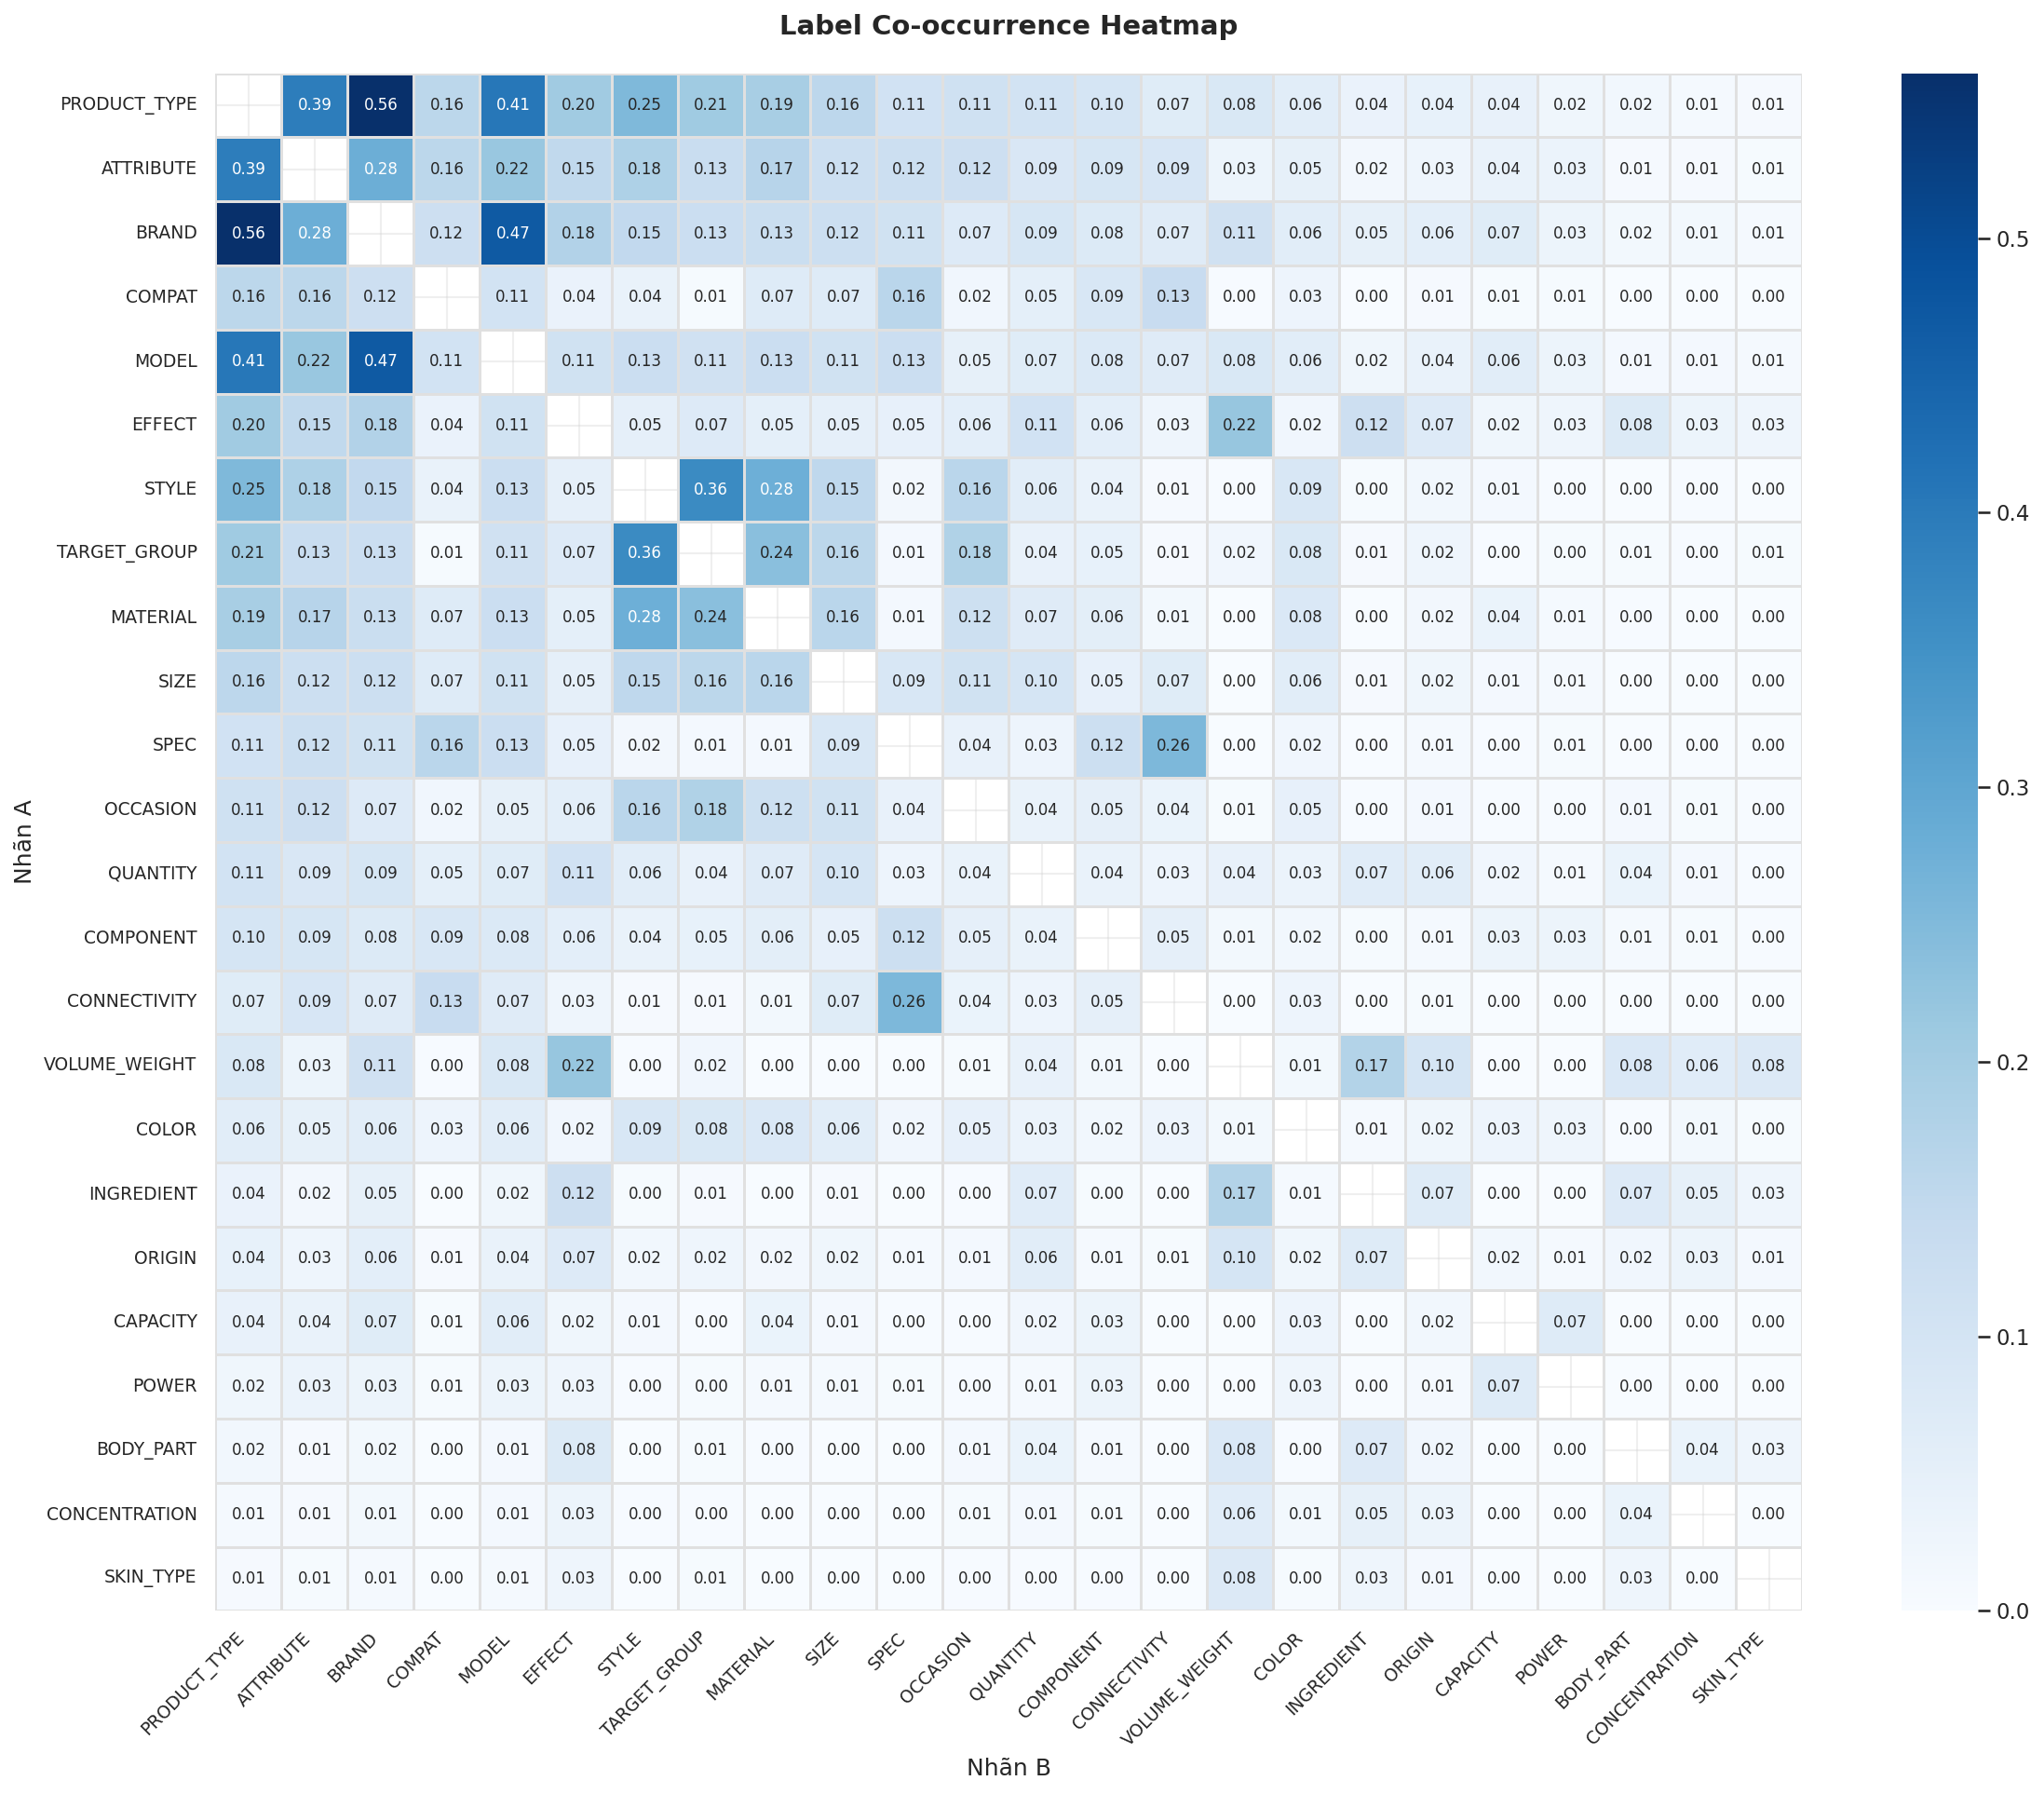

=== TOP 10 CẶP NHÃN HAY XUẤT HIỆN CÙNG NHAU NHẤT ===
  PRODUCT_TYPE + BRAND: Jaccard=0.560 (1673 tiêu đề)
  BRAND + MODEL: Jaccard=0.469 (925 tiêu đề)
  PRODUCT_TYPE + MODEL: Jaccard=0.406 (1212 tiêu đề)
  PRODUCT_TYPE + ATTRIBUTE: Jaccard=0.395 (1176 tiêu đề)
  STYLE + TARGET_GROUP: Jaccard=0.364 (366 tiêu đề)
  ATTRIBUTE + BRAND: Jaccard=0.279 (623 tiêu đề)
  STYLE + MATERIAL: Jaccard=0.277 (289 tiêu đề)
  SPEC + CONNECTIVITY: Jaccard=0.255 (106 tiêu đề)
  PRODUCT_TYPE + STYLE: Jaccard=0.253 (753 tiêu đề)
  TARGET_GROUP + MATERIAL: Jaccard=0.237 (229 tiêu đề)


In [138]:
# BIỂU ĐỒ 2.6: LABEL CO-OCCURRENCE HEATMAP (Jaccard)

title_labels = df_ent.groupby('id')['label'].apply(list)

all_labels_sorted = sorted(df_ent['label'].unique())
cooccur_matrix = pd.DataFrame(0, index=all_labels_sorted, columns=all_labels_sorted)

for labels_in_title in title_labels:
    unique_labels = set(labels_in_title)
    for pair in combinations(unique_labels, 2):
        cooccur_matrix.loc[pair[0], pair[1]] += 1
        cooccur_matrix.loc[pair[1], pair[0]] += 1
    for lbl in unique_labels:
        cooccur_matrix.loc[lbl, lbl] += 1

# Chuẩn hóa Jaccard: count / union
total_titles_per_label = cooccur_matrix.values.diagonal()
norm_matrix = cooccur_matrix.copy().astype(float)
for i, lbl_i in enumerate(all_labels_sorted):
    for j, lbl_j in enumerate(all_labels_sorted):
        if i != j:
            union = total_titles_per_label[i] + total_titles_per_label[j] - cooccur_matrix.loc[lbl_i, lbl_j]
            norm_matrix.loc[lbl_i, lbl_j] = cooccur_matrix.loc[lbl_i, lbl_j] / union if union > 0 else 0
        else:
            norm_matrix.loc[lbl_i, lbl_j] = 0

label_freq_order = df_ent['label'].value_counts().index.tolist()
norm_matrix = norm_matrix.loc[label_freq_order, label_freq_order]

plt.figure(figsize=(16, 13))
mask = np.eye(len(norm_matrix), dtype=bool)

sns.heatmap(norm_matrix, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, linecolor='#e0e0e0', mask=mask,
            annot_kws={'size': 8}, vmin=0, vmax=norm_matrix.values.max())

plt.title('Label Co-occurrence Heatmap',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Nhãn B', fontsize=12)
plt.ylabel('Nhãn A', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('2_5_Label_Cooccurrence_Heatmap.png', dpi=300)
plt.show()

print("=== TOP 10 CẶP NHÃN HAY XUẤT HIỆN CÙNG NHAU NHẤT ===")
upper_tri = norm_matrix.where(np.triu(np.ones(norm_matrix.shape), k=1).astype(bool))
top_pairs = upper_tri.stack().sort_values(ascending=False).head(10)
for (lbl_a, lbl_b), score in top_pairs.items():
    raw_count = cooccur_matrix.loc[lbl_a, lbl_b]
    print(f"  {lbl_a} + {lbl_b}: Jaccard={score:.3f} ({int(raw_count)} tiêu đề)")


**Nhận xét (Biểu đồ 2.4 – 2.6):**

- **Biểu đồ 2.4, 2.5 Phân bố của IAA sample:** Biểu đồ so sánh phân phối nhãn giữa tập mẫu IAA (n=300) và tập dữ liệu còn lại (n=2695) cho thấy sự đồng nhất về mặt thống kê. Các nhãn chủ đạo như PRODUCT_TYPE, ATTRIBUTE, BRAND duy trì tỷ trọng cân bằng. Độ lệch tỷ lệ nhãn giữa mẫu IAA và toàn bộ dataset được kiểm soát trong ngưỡng an toàn (2%). Điều này khẳng định tập mẫu dùng để đánh giá độ đồng thuận giữa các annotator là đại diện mẫu có độ tin cậy cao, đảm bảo rằng kết quả đánh giá chất lượng gán nhãn không bị chệch do sai lệch phân phối.

- **Biểu đồ 2.6 (Co-occurrence Heatmap):** Cho thấy các cặp nhãn thường xuất hiện cùng nhau trong một tiêu đề (ví dụ `BRAND` + `PRODUCT_TYPE`, `MODEL` + `SPEC`), gợi ý các mẫu cấu trúc câu phổ biến mà mô hình cần học.


---
## 3. Phân bố độ dài span theo nhãn

Phân tích số từ (word count) của mỗi thực thể, theo từng nhãn, để hiểu đặc tính ngắn/dài của từng loại thực thể.

In [139]:
df_ent['word_count'] = df_ent['entity_text'].astype(str).apply(lambda x: len(x.split()))

def categorize_length(words):
    if words <= 2:
        return 'Ngắn (1-2 từ)'
    elif words <= 6:
        return 'Trung bình (3-6 từ)'
    else:
        return 'Dài (>6 từ)'

df_ent['length_category'] = df_ent['word_count'].apply(categorize_length)

/tmp/ipykernel_58/2697282684.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(data=avg_length, x='word_count', y='label', palette='magma')


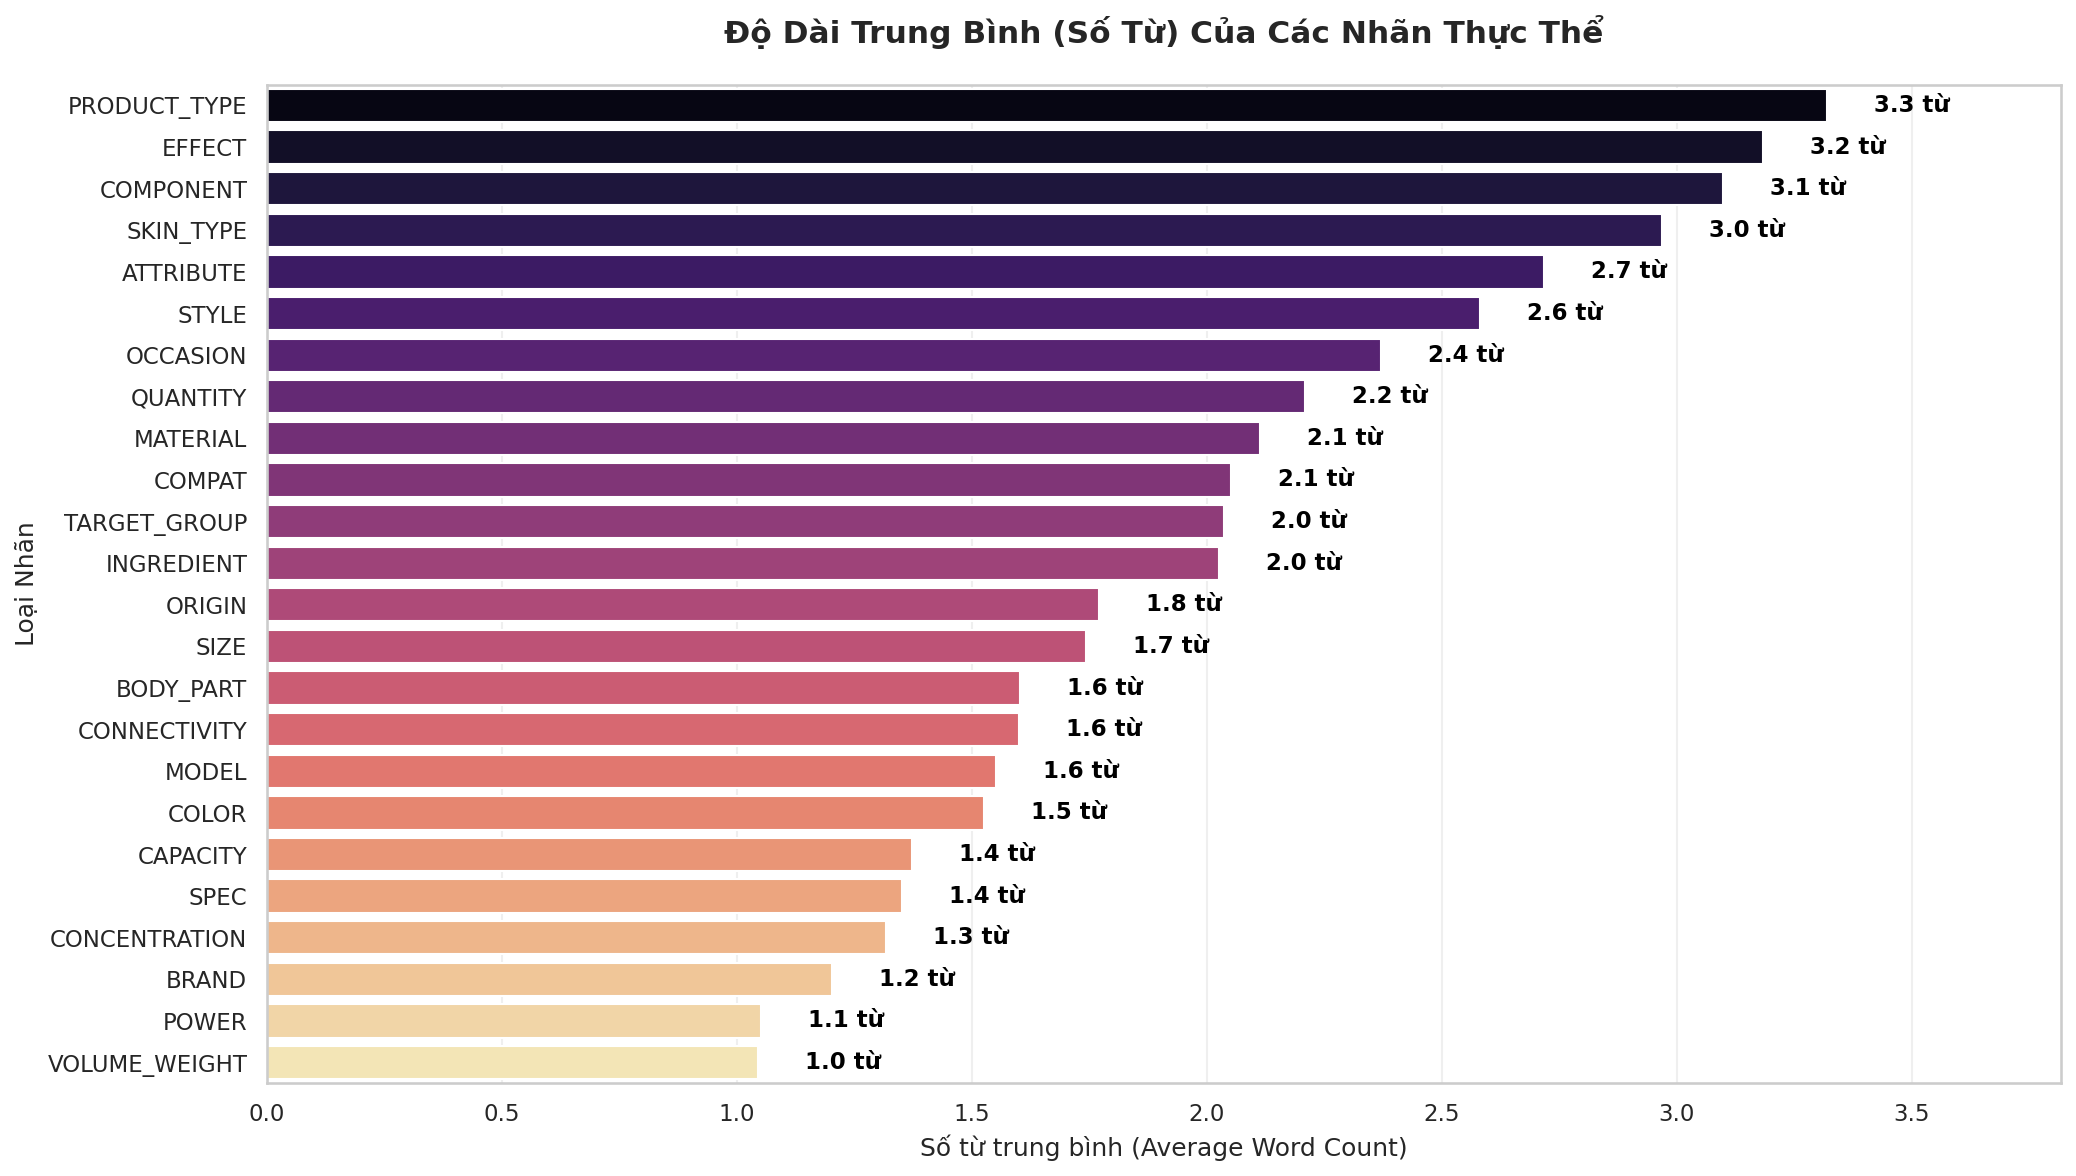

In [140]:
# BIỂU ĐỒ 3.1: ĐỘ DÀI TRUNG BÌNH CỦA ENTITY THEO TỪNG NHÃN

plt.figure(figsize=(14, 8))

df_ent['word_count'] = df_ent['entity_text'].astype(str).apply(lambda x: len(x.split()))

avg_length = df_ent.groupby('label')['word_count'].mean().sort_values(ascending=False).reset_index()

ax1 = sns.barplot(data=avg_length, x='word_count', y='label', palette='magma')

for p in ax1.patches:
    width = p.get_width()
    ax1.text(width + 0.1, p.get_y() + p.get_height() / 2, f'{width:.1f} từ',
             va='center', fontsize=11, fontweight='bold', color='black')

plt.title('Độ Dài Trung Bình (Số Từ) Của Các Nhãn Thực Thể', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Số từ trung bình (Average Word Count)', fontsize=12)
plt.ylabel('Loại Nhãn', fontsize=12)
plt.xlim(0, avg_length['word_count'].max() * 1.15)
plt.tight_layout()
plt.savefig("3_1_Average_Span_Length.png", dpi=300)
plt.show()


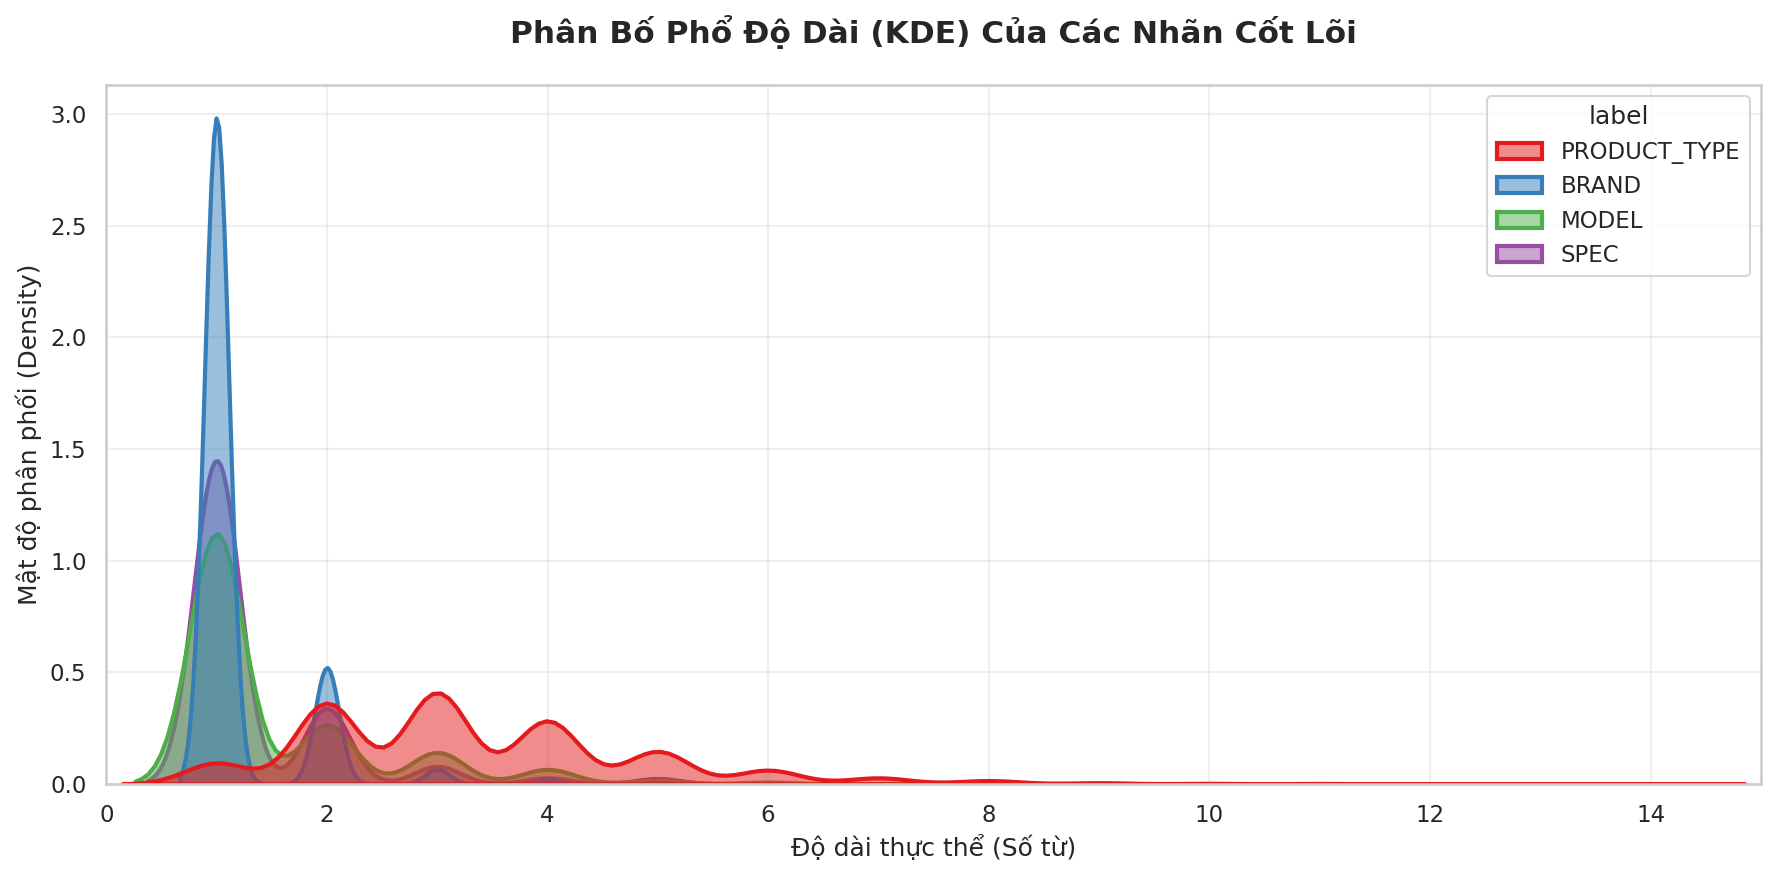

In [141]:
# BIỂU ĐỒ 3.2: KDE - PHÂN BỐ ĐỘ DÀI CỦA 4 NHÃN QUAN TRỌNG NHẤT

plt.figure(figsize=(12, 6))

key_labels = ['PRODUCT_TYPE', 'MODEL', 'BRAND', 'SPEC']
df_key = df_ent[df_ent['label'].isin(key_labels)]

sns.kdeplot(data=df_key, x='word_count', hue='label', fill=True,
            common_norm=False, palette='Set1', alpha=0.5, linewidth=2)

plt.title('Phân Bố Phổ Độ Dài (KDE) Của Các Nhãn Cốt Lõi', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Độ dài thực thể (Số từ)', fontsize=12)
plt.ylabel('Mật độ phân phối (Density)', fontsize=12)
plt.xlim(0, 15)
plt.tight_layout()
plt.savefig("3_2_Span_Length_KDE.png", dpi=300)
plt.show()

<Figure size 2100x1500 with 0 Axes>

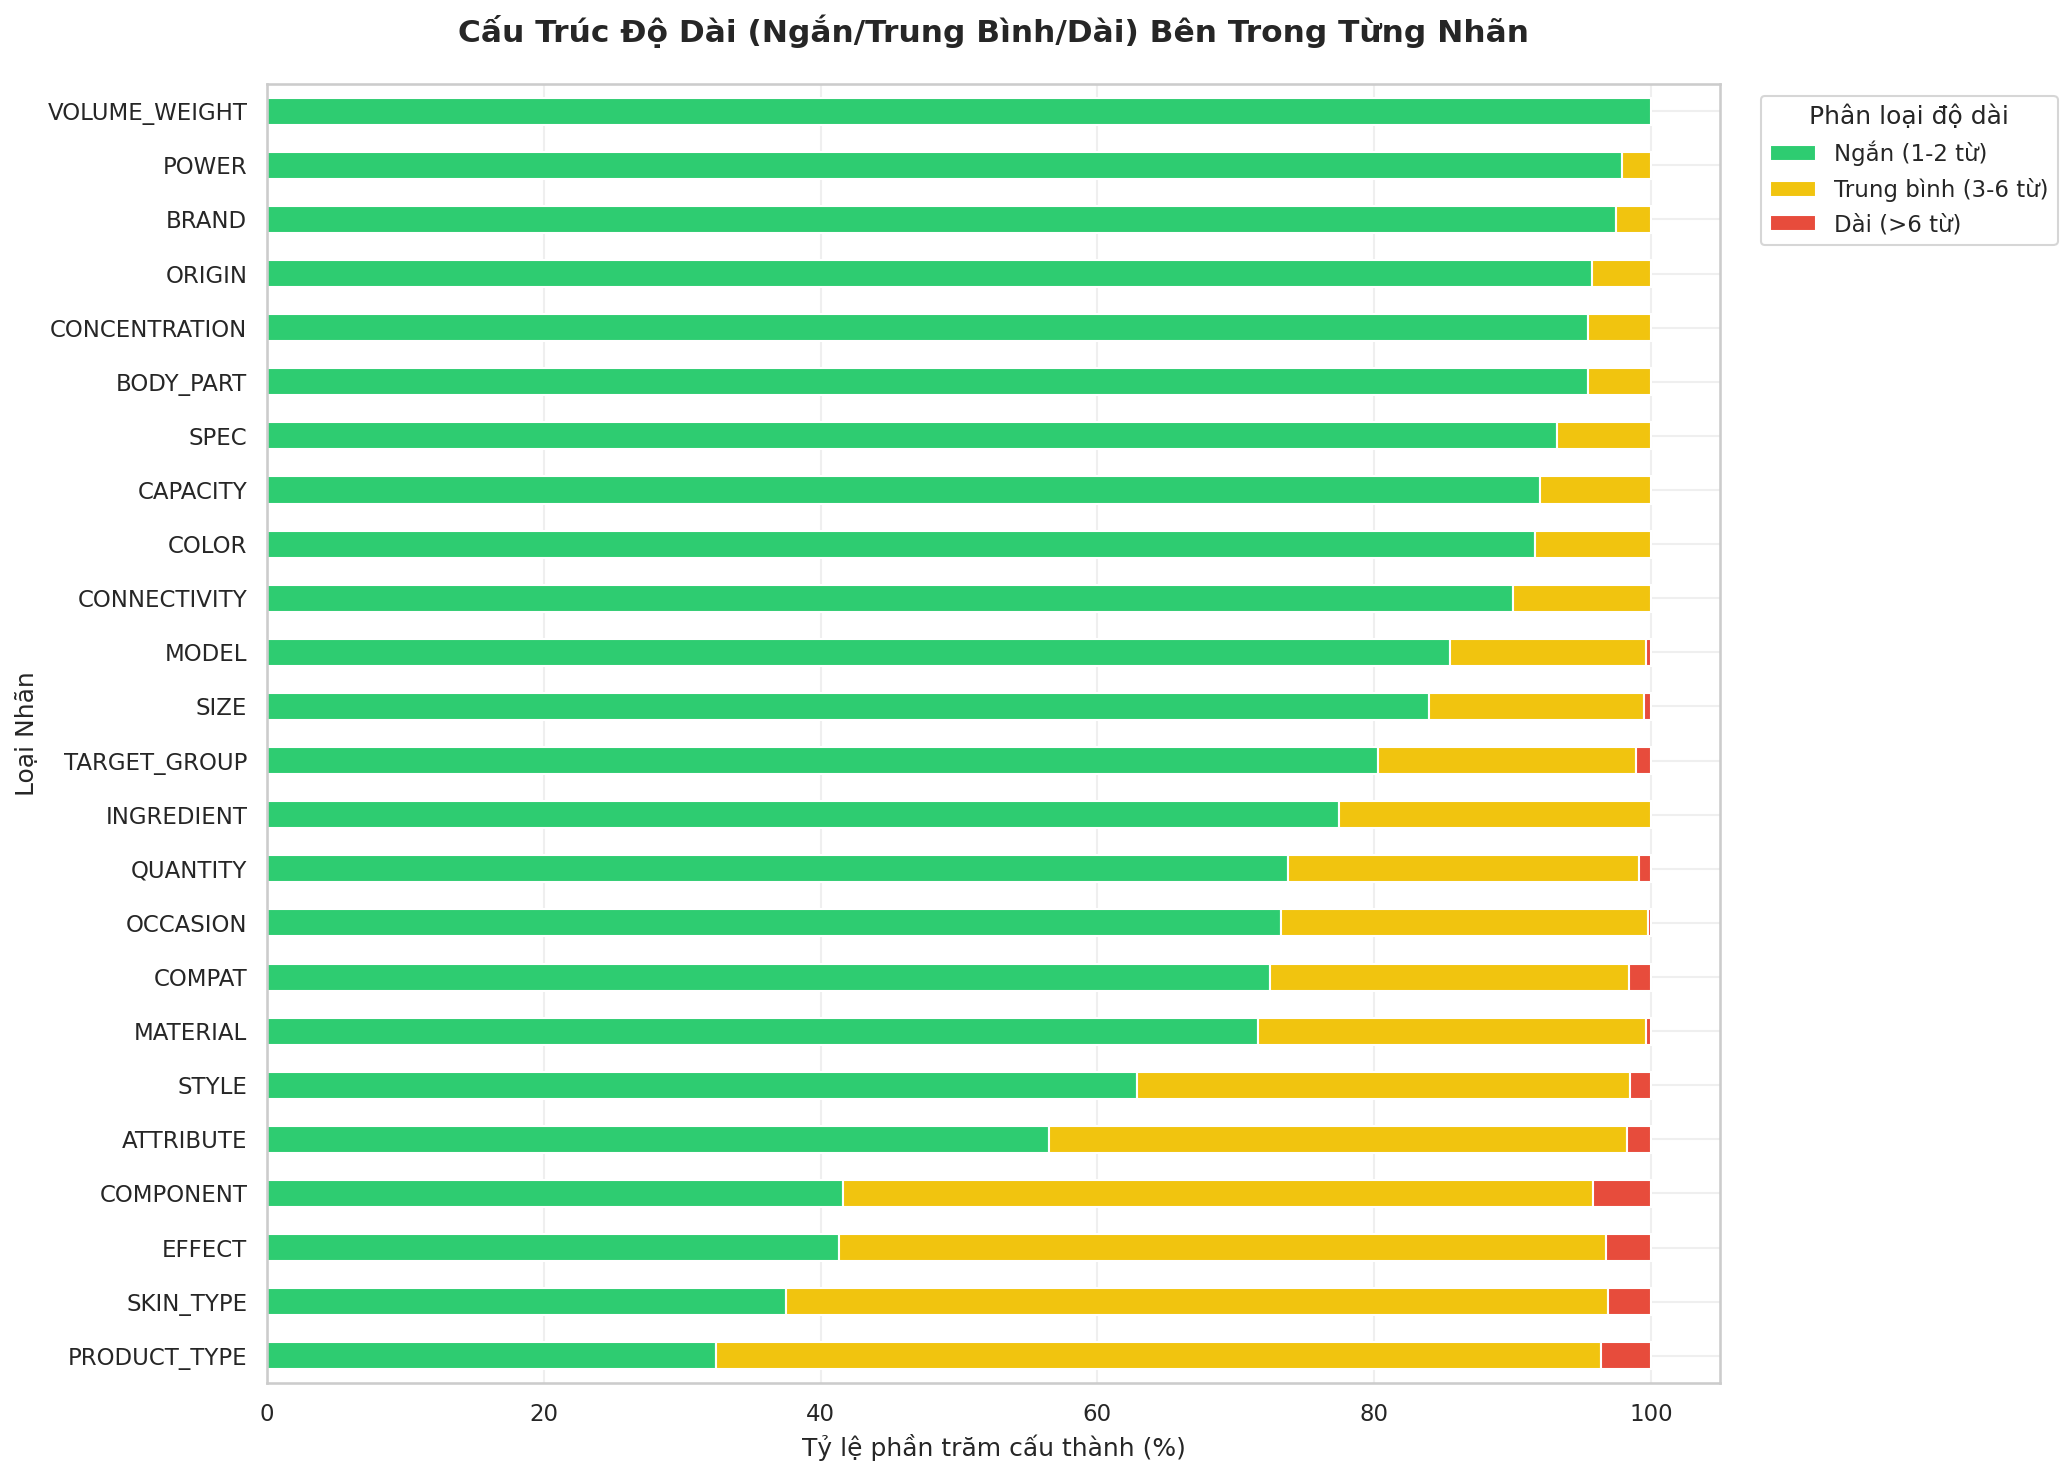

In [142]:
# BIỂU ĐỒ 3.3: TỶ LỆ ENTITY NGẮN / TRUNG BÌNH / DÀI THEO NHÃN (100% STACKED)

plt.figure(figsize=(14, 10))

length_cross = pd.crosstab(df_ent['label'], df_ent['length_category'], normalize='index') * 100

cols_order = ['Ngắn (1-2 từ)', 'Trung bình (3-6 từ)', 'Dài (>6 từ)']
length_cross = length_cross[cols_order]
length_cross = length_cross.sort_values(by='Ngắn (1-2 từ)', ascending=True)

colors = ['#2ecc71', '#f1c40f', '#e74c3c']
length_cross.plot(kind='barh', stacked=True, figsize=(14, 10), color=colors, edgecolor='white')

plt.title('Cấu Trúc Độ Dài (Ngắn/Trung Bình/Dài) Bên Trong Từng Nhãn', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Tỷ lệ phần trăm cấu thành (%)', fontsize=12)
plt.ylabel('Loại Nhãn', fontsize=12)
plt.legend(title='Phân loại độ dài', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig("3_3_Length_Category_Stacked.png", dpi=300)
plt.show()


**Nhận định:**

- **Biểu đồ 3.1 (Độ dài trung bình):** `PRODUCT_TYPE` và `EFFECT` có độ dài trung bình lớn nhất (~3–4 từ), thể hiện đặc tính cụm danh/động từ mô tả dài dòng của tiếng Việt. Ngược lại, `BRAND`, `SIZE`, `QUANTITY` cực kỳ cô đọng (chỉ 1–1.5 từ). Sự dao động này đòi hỏi mô hình phải có context window đủ rộng để không cắt cụt các thực thể dài.
- **Biểu đồ 3.2 (KDE):** Phân phối của `BRAND` và `SPEC` nhô cao và hẹp ở mốc 1–2 từ,  cấu trúc rất cứng và ổn định. Trong khi đó, `PRODUCT_TYPE` có phân phối thấp, đuôi dài tới hơn 10 từ, đây là khu vực dễ xảy ra lỗi Boundary Error (đoán sai ranh giới) nhất.
- **Biểu đồ 3.3 (Stacked theo độ dài):** Nhóm thông số kỹ thuật (`POWER`, `CAPACITY`, `CONNECTIVITY`) có tới hơn 90% là thực thể Ngắn (1–2 từ). Ngược lại, `OCCASION` và `TARGET_GROUP` chứa tỷ lệ thực thể Dài (>5 từ) đáng kể, do người bán thường nhồi cụm mô tả (ví dụ: "thích hợp đi tiệc, đi biển mùa hè").

---
## 4. Phân tích vị trí thực thể (Entity Position)

Phân tích vị trí tương đối của thực thể trong tiêu đề (đầu/giữa/cuối) để hiểu hành vi đặt từ khóa của người bán.

In [143]:
# 1. Tính vị trí tương đối (0.0 = đầu câu, 1.0 = cuối câu)
df_ent['relative_pos'] = df_ent['start_char'] / df_ent['full_text'].str.len()

# 2. Phân loại vị trí thành 3 nhóm
def categorize_position(pos):
    if pos < 0.33: return 'Đầu (0-33%)'
    elif pos < 0.66: return 'Giữa (33-66%)'
    else: return 'Cuối (66-100%)'

df_ent['pos_category'] = df_ent['relative_pos'].apply(categorize_position)

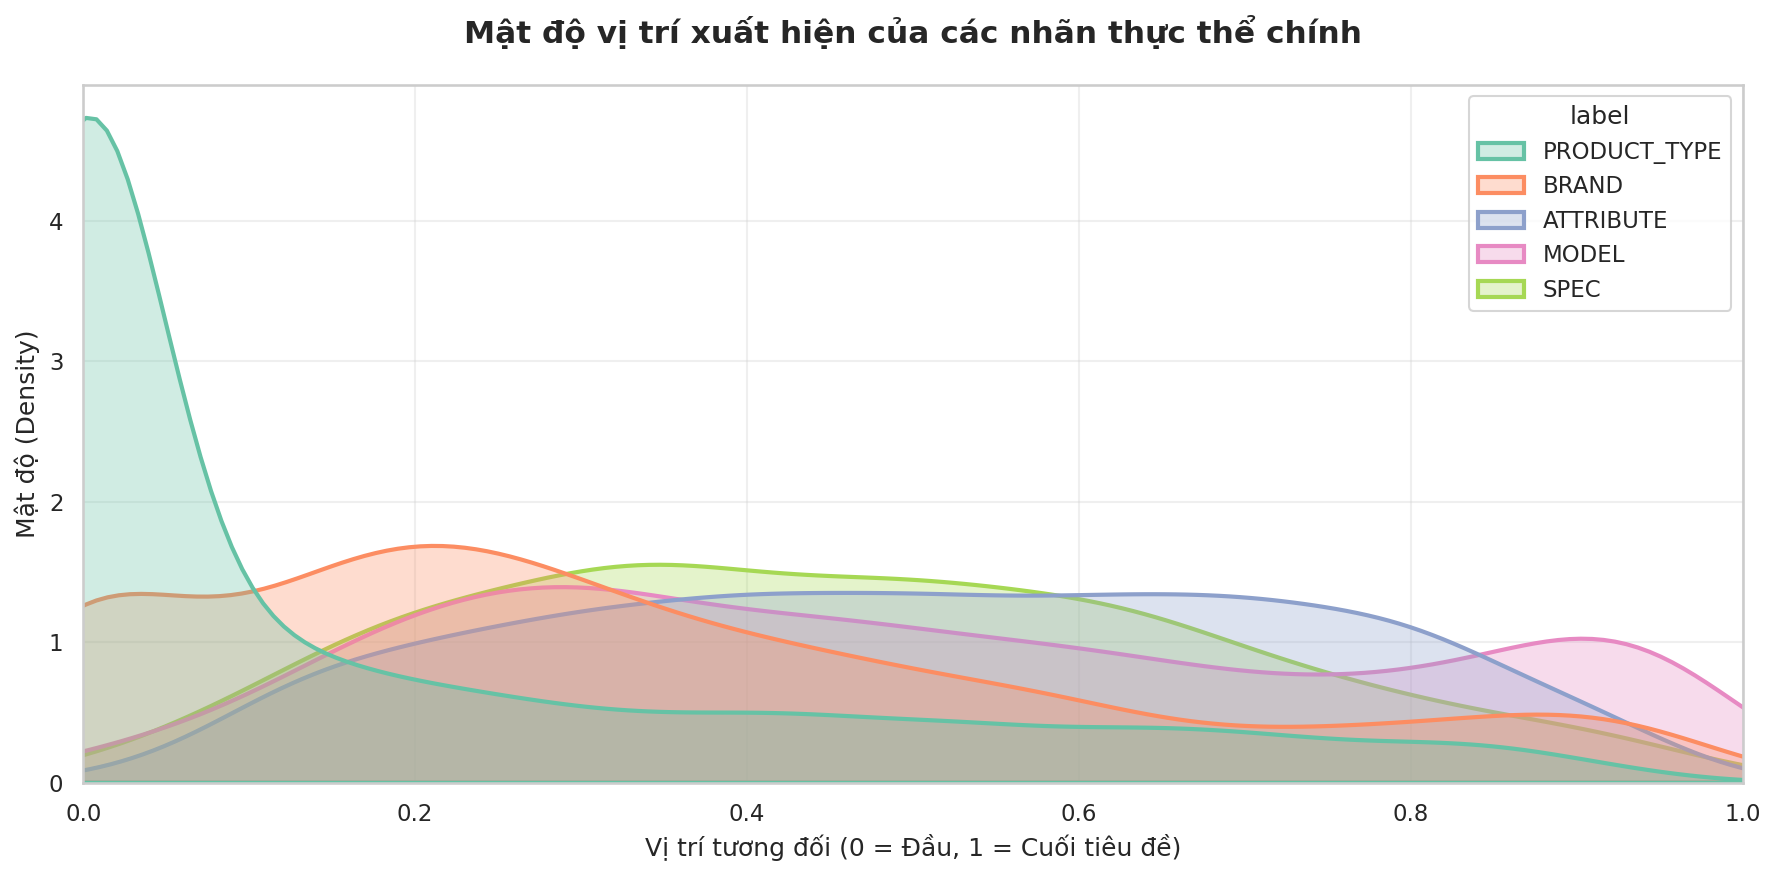

In [144]:
# BIỂU ĐỒ 4.1: DENSITY PLOT - PHÂN BỐ VỊ TRÍ CỦA CÁC NHÃN CỐT LÕI

plt.figure(figsize=(12, 6))

key_labels = ['BRAND', 'PRODUCT_TYPE', 'MODEL', 'SPEC', 'ATTRIBUTE']
df_plot = df_ent[df_ent['label'].isin(key_labels)]

sns.kdeplot(data=df_plot, x='relative_pos', hue='label', fill=True,
            common_norm=False, palette='Set2', alpha=0.3, linewidth=2)

plt.title('Mật độ vị trí xuất hiện của các nhãn thực thể chính', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Vị trí tương đối (0 = Đầu, 1 = Cuối tiêu đề)', fontsize=12)
plt.ylabel('Mật độ (Density)', fontsize=12)
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig("4_1_Entity_Position_Density.png", dpi=300)
plt.show()

<Figure size 2100x1200 with 0 Axes>

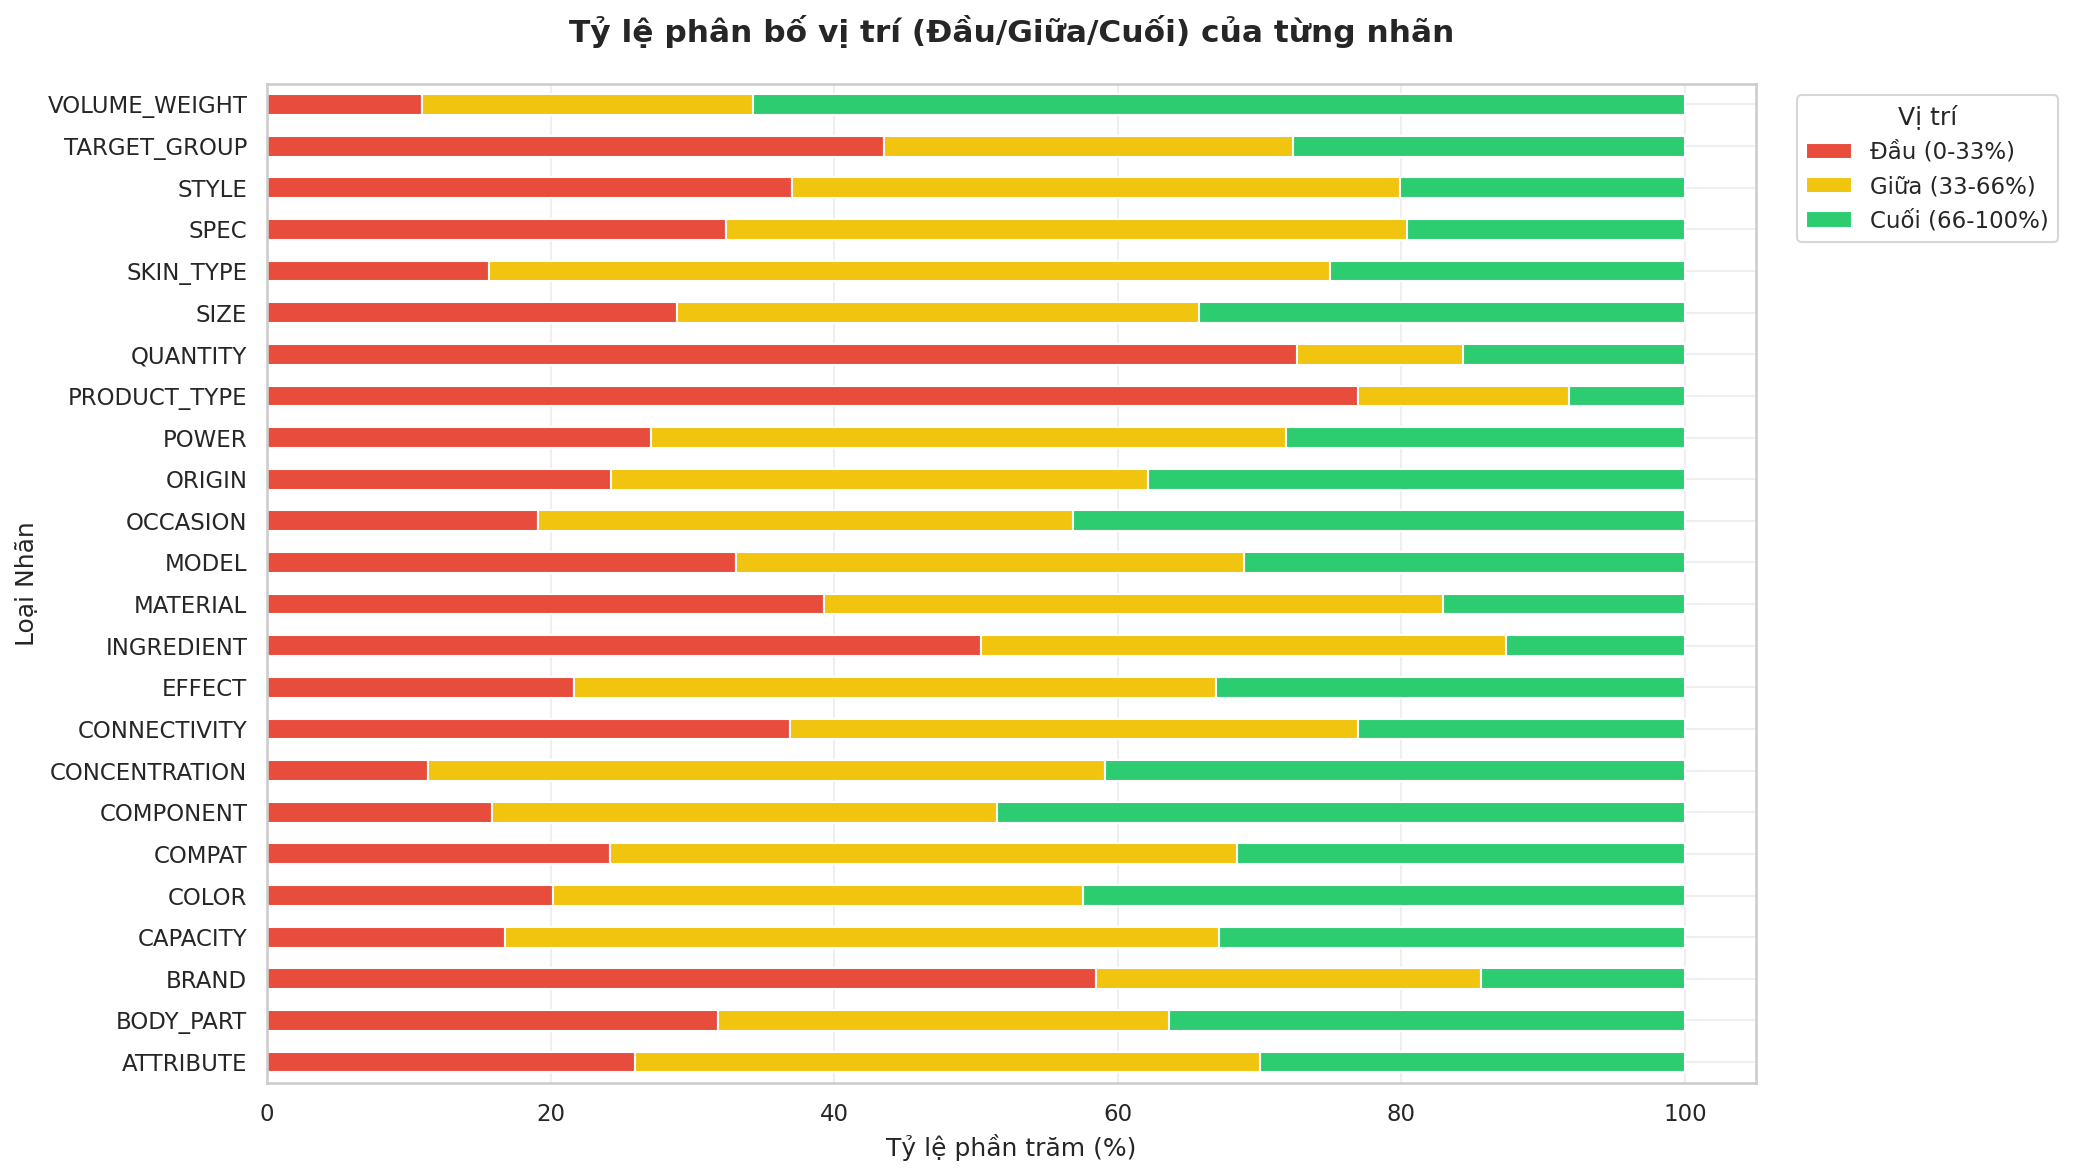

In [145]:
# BIỂU ĐỒ 4.2: STACKED BAR - TỶ LỆ VỊ TRÍ (ĐẦU/GIỮA/CUỐI) THEO NHÃN

plt.figure(figsize=(14, 8))

pos_cross = pd.crosstab(df_ent['label'], df_ent['pos_category'], normalize='index') * 100
pos_cross = pos_cross[['Đầu (0-33%)', 'Giữa (33-66%)', 'Cuối (66-100%)']]

pos_cross.plot(kind='barh', stacked=True, figsize=(14, 8), color=['#e74c3c', '#f1c40f', '#2ecc71'], edgecolor='white')

plt.title('Tỷ lệ phân bố vị trí (Đầu/Giữa/Cuối) của từng nhãn', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Tỷ lệ phần trăm (%)', fontsize=12)
plt.ylabel('Loại Nhãn', fontsize=12)
plt.legend(title='Vị trí', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig("4_2_Entity_Position_Stacked.png", dpi=300)
plt.show()


**Nhận xét:**

- **Biểu đồ 4.1 (Density Plot):** `BRAND` và `PRODUCT_TYPE` có mật độ tập trung rất cao ở phía đầu tiêu đề (0.0–0.3) — người bán luôn ưu tiên đặt thương hiệu và tên sản phẩm lên đầu để tối ưu hiển thị SEO. Ngược lại, `SPEC` (thông số) có mật độ dâng cao ở nửa sau, phản ánh hành vi cung cấp chi tiết kỹ thuật sau cùng.
- **Biểu đồ 4.2 (Stacked Bar):** `BRAND` có tỷ lệ xuất hiện ở vị trí "Đầu" chiếm áp đảo (gần 60%). Các nhãn bổ trợ như `ATTRIBUTE` hay `COLOR` phân bố khá đều ở "Giữa" và "Cuối", cho thấy sự linh hoạt khi người bán muốn nhấn mạnh các tính năng nổi bật.


---
## 5. Phân tích Code-switching (Tiếng Anh – Tiếng Việt)

Phân tích mức độ pha trộn ngôn ngữ Anh–Việt trong tiêu đề và trong từng loại thực thể, một đặc trưng phổ biến của TMĐT Việt Nam.

In [146]:
import re
import nltk
from nltk.corpus import words

# 1. Tải từ điển Anh chuẩn (chỉ cần chạy lần đầu)
nltk.download('words', quiet=True)
english_vocab = set(w.lower() for w in words.words())

# 2. Định nghĩa các tập ký tự & từ khóa
VN_CHARS = r'[àáảãạăằắẳẵặâầấẩẫậèéẻẽẹêềếểễệđìíỉĩịòóỏõọôồốổỗộơờớởỡợùúủũụưừứửữựỳýỷỹỵ]'
VN_PATTERN = re.compile(VN_CHARS, re.IGNORECASE)

# Những từ tiếng Việt không dấu phổ biến trong E-commerce (tránh lọc nhầm là tiếng Anh)
COMMON_VN_NO_ACCENT = {'cho', 'tai', 'nghe', 'thun', 'mi', 'treo', 'nam', 'kem', 'bao', 'da','loa', }


def analyze_language_profile(text):
    """Phân tích ngôn ngữ cho một tiêu đề TMĐT.
    Trả về: (Loại profile, Tỷ lệ tiếng Anh thuần)
    """
    if not isinstance(text, str) or not text.strip():
        return "Unknown", 0.0

    tokens = re.findall(r'\b\w+\b', text.lower())

    vi_count = 0
    en_count = 0

    for token in tokens:
        if VN_PATTERN.search(token):
            vi_count += 1
        elif token in COMMON_VN_NO_ACCENT:
            vi_count += 1
        elif token in english_vocab:
            en_count += 1

    total_valid = vi_count + en_count
    if total_valid == 0:
        return "Nhiễu/Số", 0.0

    en_ratio = en_count / total_valid

    if en_ratio >= 0.90: return "Thuần Anh", en_ratio
    if en_ratio <= 0.10: return "Thuần Việt", en_ratio
    if en_ratio > 0.50:  return "Code-switching (Thiên Anh)", en_ratio
    return "Code-switching (Thiên Việt)", en_ratio


# --- ÁP DỤNG CHO TOÀN BỘ TIÊU ĐỀ ---
results = df_titles['full_text'].apply(analyze_language_profile)
df_titles['lang_profile'] = [res[0] for res in results]
df_titles['en_ratio'] = [res[1] for res in results]

print("=== PHÂN LOẠI NGÔN NGỮ TIÊU ĐỀ ===")
print(df_titles['lang_profile'].value_counts())


=== PHÂN LOẠI NGÔN NGỮ TIÊU ĐỀ ===
lang_profile
Code-switching (Thiên Việt)    1634
Thuần Việt                     1295
Code-switching (Thiên Anh)       64
Name: count, dtype: int64


<Figure size 2100x1200 with 0 Axes>

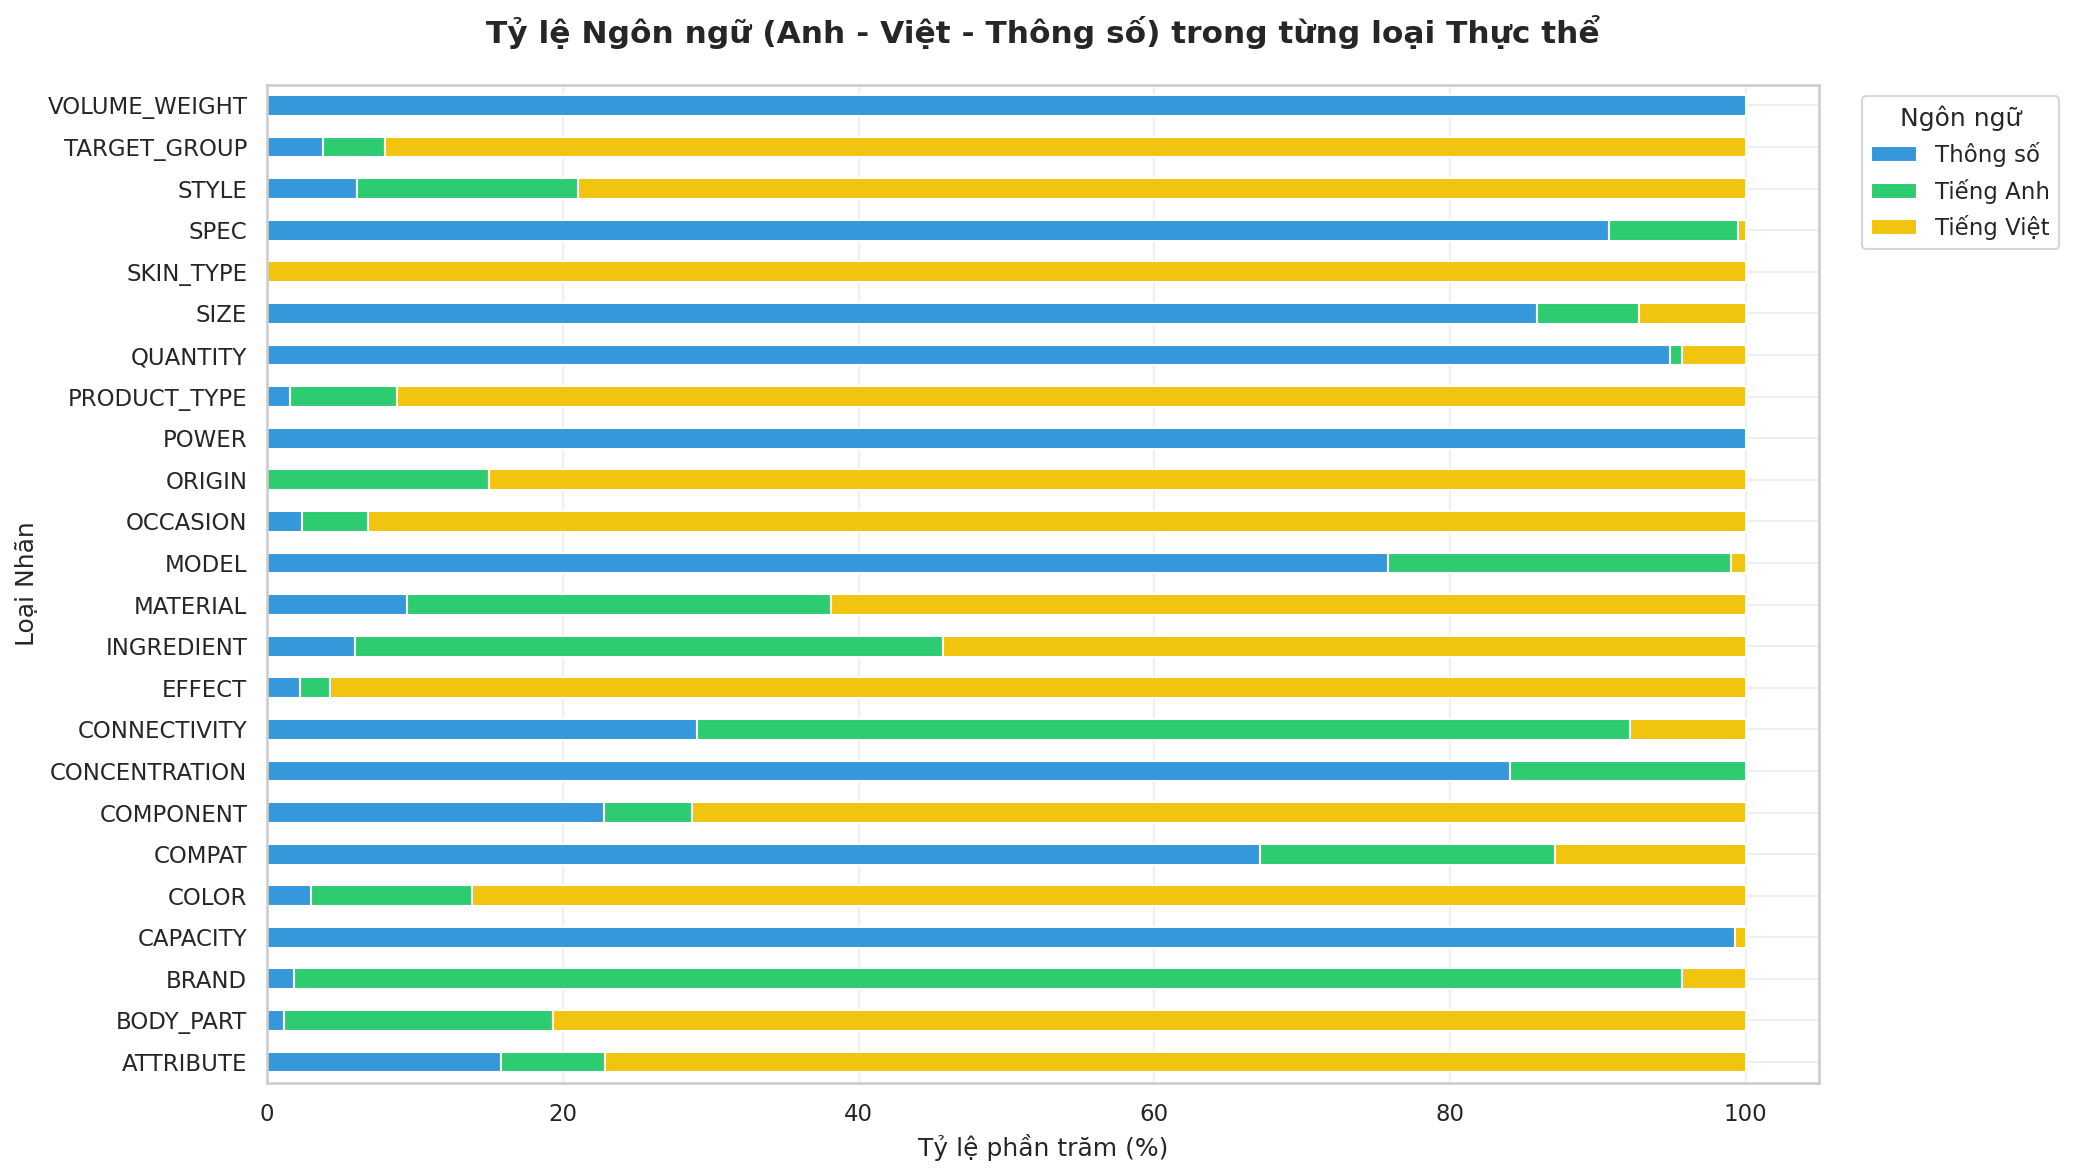

In [147]:
# BIỂU ĐỒ 5.1: TỶ LỆ NGÔN NGỮ TRONG TỪNG LOẠI THỰC THỂ

COMMON_VN_NO_ACCENT = {'cho', 'tai', 'nghe', 'thun', 'mi', 'treo', 'nam', 'kem', 'bao', 'da', 'loa'}

def classify_token(text):
    # 1. Kiểm tra THÔNG SỐ 
    if any(char.isdigit() for char in str(text)):
        return 'Thông số'
    
    # 2. Kiểm tra TIẾNG VIỆT (Dùng pattern dấu như hàm analyze_language_profile)
    if VN_PATTERN.search(str(text)):
        return 'Tiếng Việt'
    if str(text).lower() in COMMON_VN_NO_ACCENT:
        return 'Tiếng Việt'
        
    # 3. TIẾNG ANH (Mặc định)
    return 'Tiếng Anh'

def classify_token_safe(text):
    if pd.isna(text) or str(text).strip() == "":
        return 'Unknown'
    
    return classify_token(text)

# Áp dụng vào DataFrame
df_ent['lang_group'] = df_ent['entity_text'].apply(classify_token_safe)


df_ent['lang_group'] = df_ent['entity_text'].apply(classify_token_safe)

plt.figure(figsize=(14, 8))
lang_grouped = pd.crosstab(df_ent['label'], df_ent['lang_group'], normalize='index') * 100
lang_grouped.plot(kind='barh', stacked=True, figsize=(14, 8), color=['#3498db', '#2ecc71', '#f1c40f'], edgecolor='white')
plt.title('Tỷ lệ Ngôn ngữ (Anh - Việt - Thông số) trong từng loại Thực thể', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Tỷ lệ phần trăm (%)')
plt.ylabel('Loại Nhãn')
plt.legend(title='Ngôn ngữ', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig("5_1_Codeswitching_Entity.png", dpi=300)
plt.show()


**Nhận xét:** Phần lớn tiêu đề ở nhóm "Thuần Việt" hoặc "Code-switching (Thiên Việt)", phản ánh đặc thù ngôn ngữ TMĐT Việt Nam, thể hiện qua `PRODUCT_TYPE` có tỉ lệ tiếng Việt chiếm đa số. Tuy nhiên một số nhãn như `BRAND` và `MODEL` có tỷ lệ Tiếng Anh/Thông số cao hơn rõ rệt so với mặt bằng chung — đây là các thực thể thường giữ nguyên dạng gốc (tên thương hiệu quốc tế, mã sản phẩm).

---
## 6. Phân tích tính nhất quán

Kiểm tra phân bố chất lượng gán nhãn, và các thực thể bị gán nhãn không nhất quán (conflict).

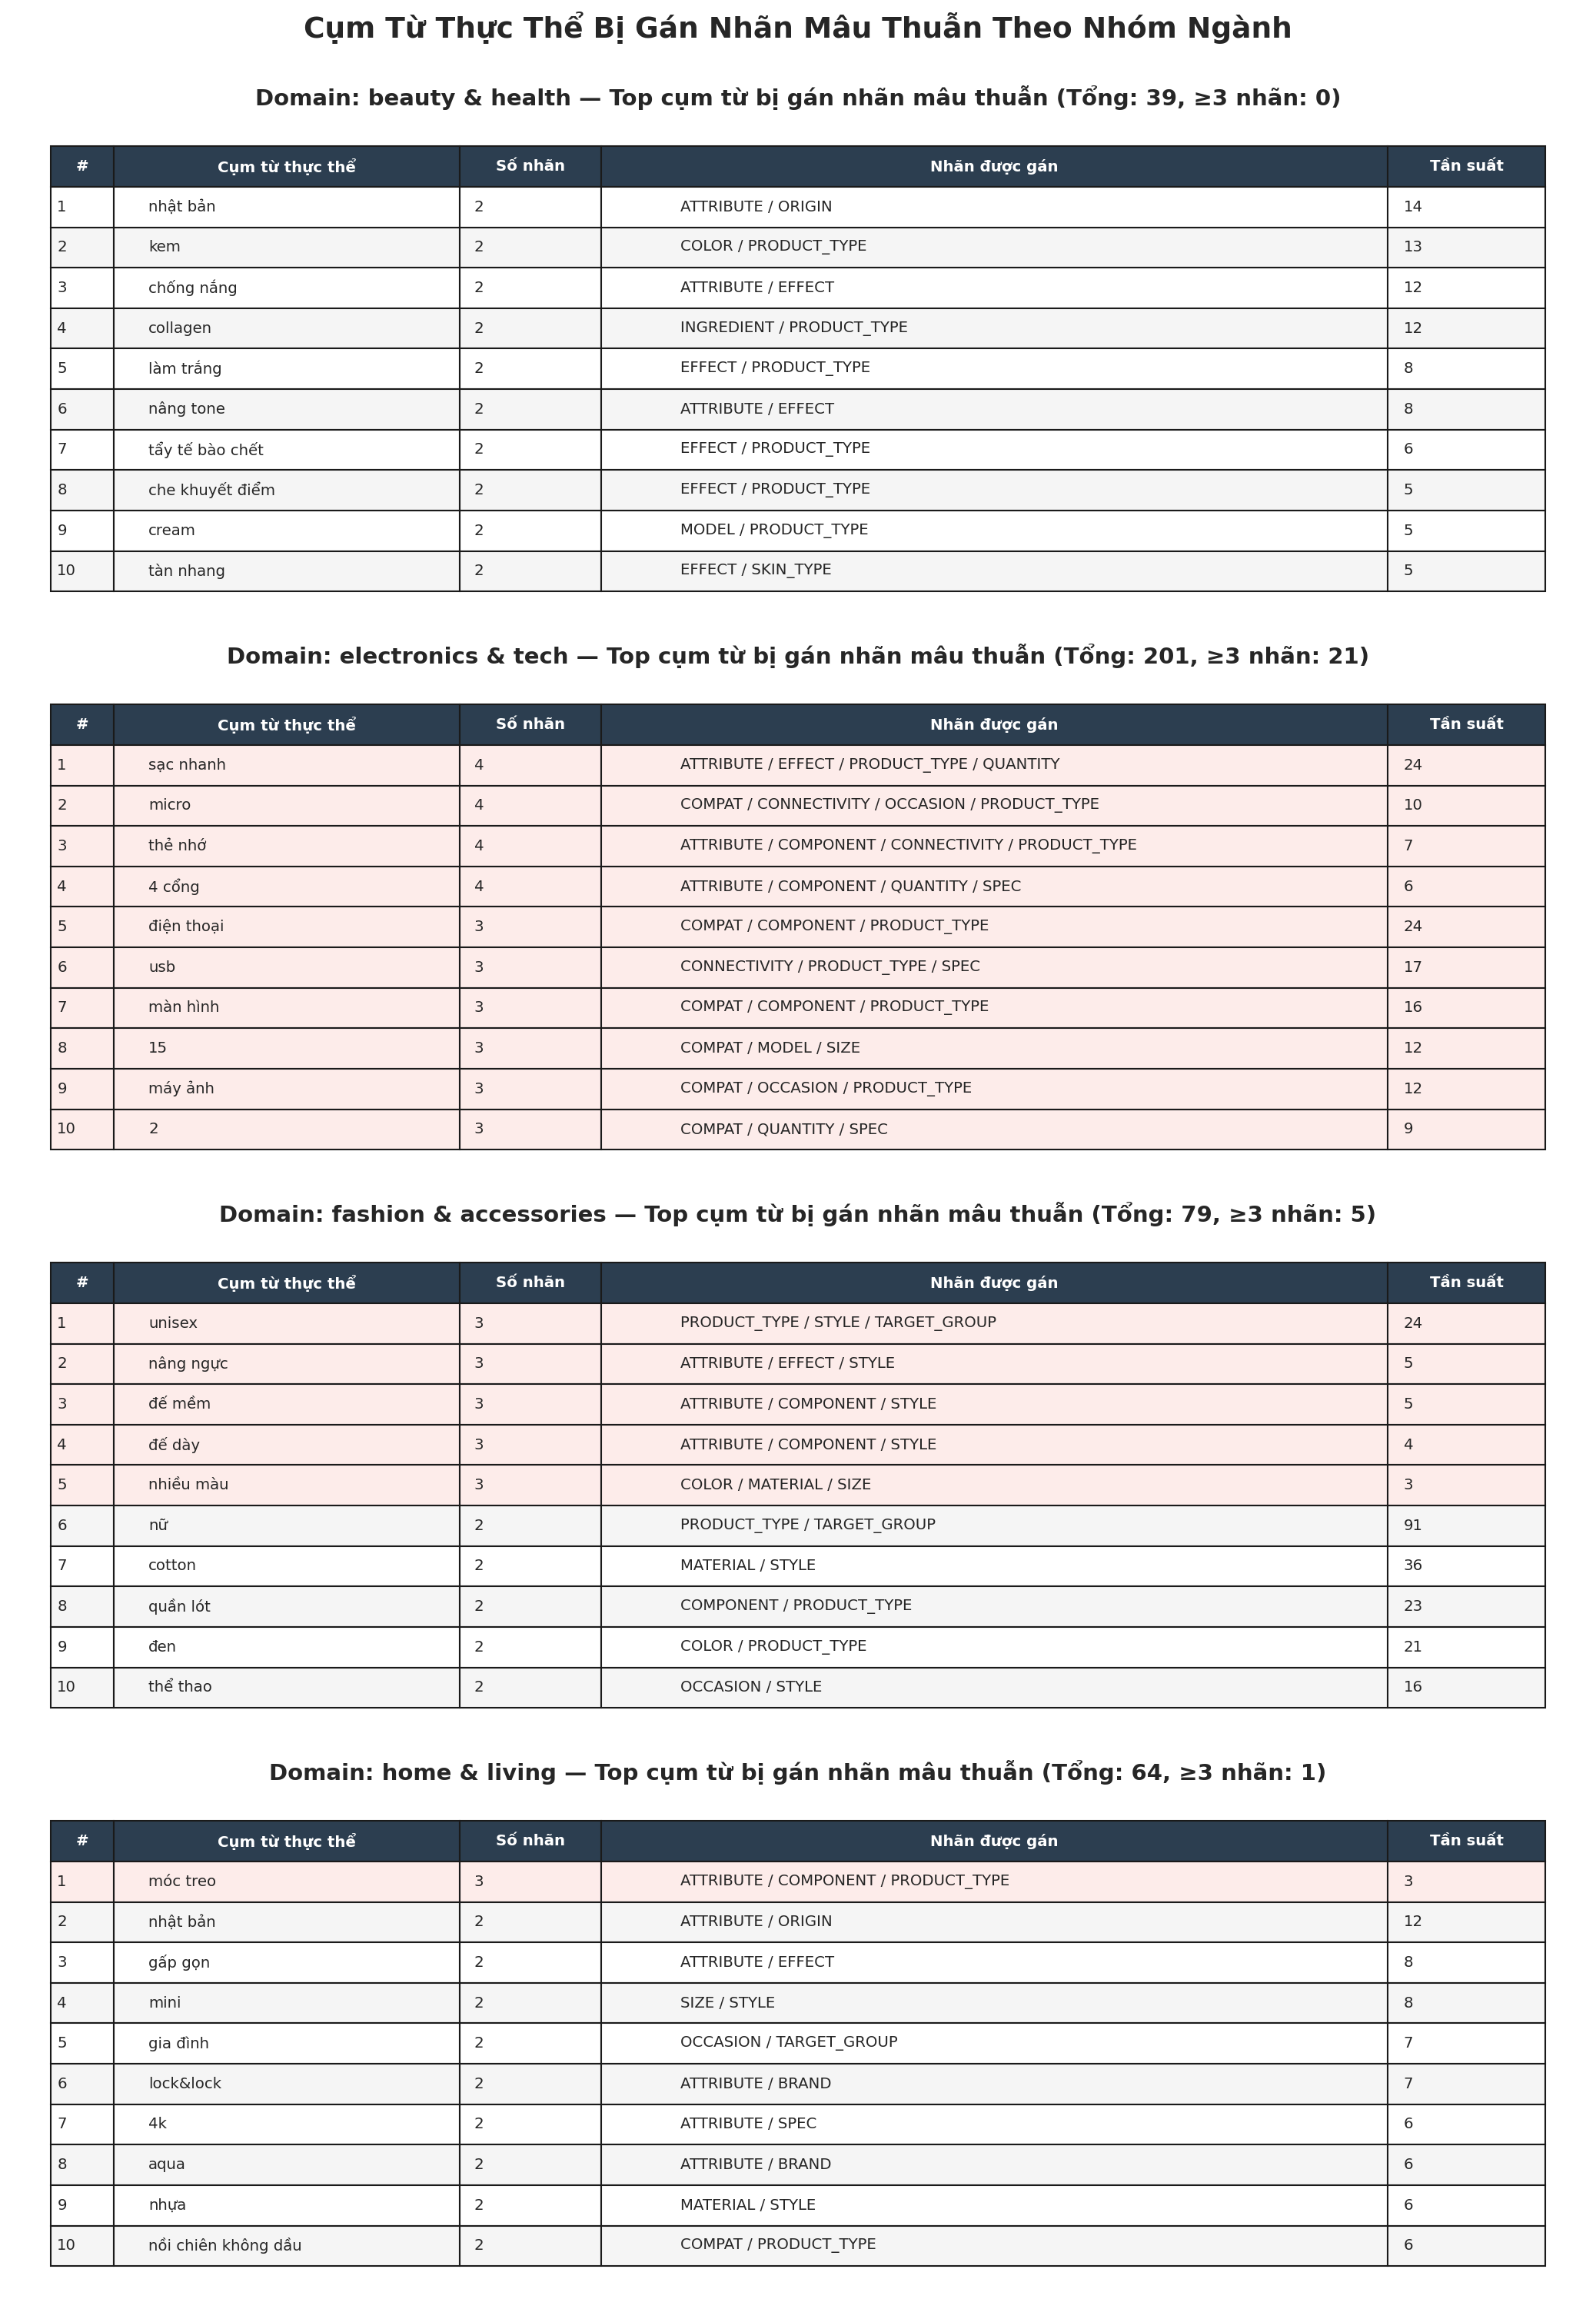

=== TỔNG HỢP THEO DOMAIN ===
- beauty & health: 39 cụm từ bị gán ≥2 nhãn, trong đó 0 cụm bị ≥3 nhãn (conflict nghiêm trọng).
- electronics & tech: 201 cụm từ bị gán ≥2 nhãn, trong đó 21 cụm bị ≥3 nhãn (conflict nghiêm trọng).
- fashion & accessories: 79 cụm từ bị gán ≥2 nhãn, trong đó 5 cụm bị ≥3 nhãn (conflict nghiêm trọng).
- home & living: 64 cụm từ bị gán ≥2 nhãn, trong đó 1 cụm bị ≥3 nhãn (conflict nghiêm trọng).


In [148]:
# BIỂU ĐỒ 6.1: TOP CỤM TỪ THỰC THỂ BỊ GÁN NHÃN MÂU THUẪN, PHÂN THEO DOMAIN

df_ent['entity_lower'] = df_ent['entity_text'].str.lower().str.strip()

results = []
for industry_group, df_gr in df_ent.groupby('industry_group'):
    entity_label_groups = df_gr.groupby('entity_lower').agg(
        labels=('label', lambda x: sorted(x.unique().tolist())),
        num_labels=('label', 'nunique'),
        count=('label', 'count')
    ).reset_index()
    ambiguous = entity_label_groups[entity_label_groups['num_labels'] >= 2].copy()
    ambiguous['industry_group'] = industry_group
    results.append(ambiguous)

all_ambiguous = pd.concat(results, ignore_index=True)
all_ambiguous['labels_str'] = all_ambiguous['labels'].apply(lambda x: ' / '.join(x))
all_ambiguous = all_ambiguous.sort_values(['industry_group', 'num_labels', 'count'], ascending=[True, False, False])

top_per_domain = all_ambiguous.groupby('industry_group').head(10).reset_index(drop=True)

domains = top_per_domain['industry_group'].unique()
n_domains = len(domains)

fig, axes = plt.subplots(n_domains, 1, figsize=(14, 5 * n_domains))
if n_domains == 1:
    axes = [axes]

for ax, industry_group in zip(axes, domains):
    ax.axis('off')
    sub = top_per_domain[top_per_domain['industry_group'] == industry_group].reset_index(drop=True)

    table_data = [['#', 'Cụm từ thực thể', 'Số nhãn', 'Nhãn được gán', 'Tần suất']]
    for i, row in sub.iterrows():
        table_data.append([
            str(i + 1),
            row['entity_lower'],
            str(row['num_labels']),
            row['labels_str'],
            str(row['count'])
        ])

    col_widths = [0.04, 0.22, 0.09, 0.50, 0.10]
    table = ax.table(
        cellText=table_data[1:],
        colLabels=table_data[0],
        colWidths=col_widths,
        cellLoc='left',
        loc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9.5)
    table.scale(1, 1.6)

    for j in range(len(table_data[0])):
        table[0, j].set_facecolor('#2c3e50')
        table[0, j].set_text_props(color='white', fontweight='bold')

    for i in range(1, len(table_data)):
        n_labels = int(table_data[i][2])
        for j in range(len(table_data[0])):
            if n_labels >= 3:
                table[i, j].set_facecolor('#fdecea')
            elif i % 2 == 0:
                table[i, j].set_facecolor('#f5f5f5')
            else:
                table[i, j].set_facecolor('white')

    total_dom = len(all_ambiguous[all_ambiguous['industry_group'] == industry_group])
    severe_dom = len(all_ambiguous[(all_ambiguous['industry_group'] == industry_group) & (all_ambiguous['num_labels'] >= 3)])
    ax.set_title(
        f'Domain: {industry_group} — Top cụm từ bị gán nhãn mâu thuẫn (Tổng: {total_dom}, ≥3 nhãn: {severe_dom})',
        fontsize=14, fontweight='bold'
    )

plt.suptitle('Cụm Từ Thực Thể Bị Gán Nhãn Mâu Thuẫn Theo Nhóm Ngành', fontsize=18, fontweight='bold', y=1.0)
plt.tight_layout()
plt.savefig('6_1_Ambiguous_Entity_Table_By_Domain.png', dpi=300, bbox_inches='tight')
plt.show()

print("=== TỔNG HỢP THEO DOMAIN ===")
for industry_group in domains:
    total_dom = len(all_ambiguous[all_ambiguous['industry_group'] == industry_group])
    severe_dom = len(all_ambiguous[(all_ambiguous['industry_group'] == industry_group) & (all_ambiguous['num_labels'] >= 3)])
    print(f"- {industry_group}: {total_dom} cụm từ bị gán ≥2 nhãn, trong đó {severe_dom} cụm bị ≥3 nhãn (conflict nghiêm trọng).")

**Nhận xét:**

- **Biểu đồ 6.1 Cụm từ được gán nhiều nhãn:** Xung đột nhãn tập trung nhiều nhất ở Electronics & Tech (201 cụm, 21 cụm ≥3 nhãn), do thuật ngữ kỹ thuật ngắn như "sạc nhanh", "thẻ nhớ", "USB" có thể đảm nhận nhiều vai trò khác nhau tùy ngữ cảnh. Một yếu tố chi phối quan trọng là vị trí trong tiêu đề: cùng một cụm từ khi đứng đầu thường là PRODUCT_TYPE, khi đứng giữa/cuối lại mang chức năng bổ nghĩa (COMPONENT, ATTRIBUTE, SPEC). Bên cạnh đó, một số cặp nhãn như EFFECT/PRODUCT_TYPE ("làm trắng"), SIZE/STYLE ("mini") phản ánh mơ hồ ngữ nghĩa thực sự.
